In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
data=pd.read_excel("laptop.xlsx")
recommendation_data = data.copy()


In [3]:
data.head(10)


,Date,Quantity,number,model_name,brand,processor_name,ram(GB),ssd(GB),Hard Disk(GB),Operating System,graphics,screen_size(inches),resolution (pixels),no_of_cores,no_of_threads,spec_score,price
0,2023-01-01,1,83,Samsung Galaxy Book 3 Pro 360 NP960QFG-KA3IN L...,Samsung,13th Gen Core i7,16,1000,0,Windows,Intel Iris Xe Graphics,16.0,2880 x 1800,12,16,82,27300
1,2023-01-01,1,1010,HP 15s-du3519TX Laptop,HP,11th Gen Core i5,8,512,0,Windows,2 GB NVIDIA GeForce MX450,15.6,1920 x 1080,4,8,62,21500
2,2023-01-01,1,357,Lenovo Yoga 9i 82BG005JIN Laptop,Lenovo,11th Gen Core i7,16,1000,0,Windows,Intel Iris Xe Graphics,14.0,3840 x 2160,4,8,67,27300
3,2023-01-01,1,190,Lenovo E41-55 82FJ00ALIH Laptop,Lenovo,Athlon 3150U,4,0,1000,DOS,AMD Radeon AMD,14.0,1366 x 768,2,2,48,14000
4,2023-01-02,1,629,Lenovo IdeaPad Slim 5 82FG01HAIN Laptop,Lenovo,11th Gen Core i5,16,512,0,Windows,Intel Iris Xe Graphics,15.6,1920 x 1080,4,8,53,22300
5,2023-01-02,1,498,Asus VivoBook 15 2022 X515JA-EJ592WS Laptop,Asus,10th Gen Core i5,8,512,0,Windows,Intel Integrated UHD,15.6,1920 x 1080,4,8,59,21500
6,2023-01-02,1,274,HP 15s- fr2512TU Laptop,HP,11th Gen Core i3,8,256,0,Windows,Intel UHD Graphics,15.6,1920 x 1080,4,8,47,15500
7,2023-01-03,1,315,Dell Latitude 3420 Laptop,Dell,11th Gen Core i5,16,256,1000,Windows,Intel UHD Graphics,14.0,1366 x 768,4,8,65,20500
8,2023-01-04,1,78,Samsung Galaxy Book 3 360 13 NP730QFG-KA2IN La...,Samsung,13th Gen Core i7,16,512,0,Windows,Intel Iris Xe Graphics,13.3,1920 x 1080,10,12,67,27300
9,2023-01-05,1,78,Samsung Galaxy Book 3 360 13 NP730QFG-KA2IN La...,Samsung,13th Gen Core i7,16,512,0,Windows,Intel Iris Xe Graphics,13.3,1920 x 1080,10,12,67,27300


In [4]:
data.loc[356, "processor_name"] = "12th Gen Core i7"
data = data[
    data["model_name"] != "Infinix Zero Book Ultra Laptop"
]
recommendation_datadata = data[
    recommendation_data["model_name"] != "Infinix Zero Book Ultra Laptop"
]

C:\Users\dell\AppData\Local\Temp\ipykernel_8724\1116017540.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  recommendation_datadata = data[


In [5]:
data.shape


(1875, 17)

In [6]:
data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1875 entries, 0 to 1881
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 1875 non-null   object 
 1   Quantity             1875 non-null   int64  
 2   number               1875 non-null   int64  
 3   model_name           1875 non-null   object 
 4   brand                1875 non-null   object 
 5   processor_name       1875 non-null   object 
 6   ram(GB)              1875 non-null   int64  
 7   ssd(GB)              1875 non-null   int64  
 8   Hard Disk(GB)        1875 non-null   int64  
 9   Operating System     1875 non-null   object 
 10  graphics             1875 non-null   object 
 11  screen_size(inches)  1871 non-null   float64
 12  resolution (pixels)  1868 non-null   object 
 13  no_of_cores          1875 non-null   int64  
 14  no_of_threads        1875 non-null   int64  
 15  spec_score           1875 non-null   int64 

In [7]:
data.isna().sum()


Date                   0
Quantity               0
number                 0
model_name             0
brand                  0
processor_name         0
ram(GB)                0
ssd(GB)                0
Hard Disk(GB)          0
Operating System       0
graphics               0
screen_size(inches)    4
resolution (pixels)    7
no_of_cores            0
no_of_threads          0
spec_score             0
price                  0
dtype: int64

In [8]:
data.dropna(axis=0,inplace=True)


In [9]:
data.isna().sum()


Date                   0
Quantity               0
number                 0
model_name             0
brand                  0
processor_name         0
ram(GB)                0
ssd(GB)                0
Hard Disk(GB)          0
Operating System       0
graphics               0
screen_size(inches)    0
resolution (pixels)    0
no_of_cores            0
no_of_threads          0
spec_score             0
price                  0
dtype: int64

In [10]:
data.reset_index(inplace=True)


In [11]:
data.drop(['index'],axis=1,inplace=True)

data.head()


,Date,Quantity,number,model_name,brand,processor_name,ram(GB),ssd(GB),Hard Disk(GB),Operating System,graphics,screen_size(inches),resolution (pixels),no_of_cores,no_of_threads,spec_score,price
0,2023-01-01,1,83,Samsung Galaxy Book 3 Pro 360 NP960QFG-KA3IN L...,Samsung,13th Gen Core i7,16,1000,0,Windows,Intel Iris Xe Graphics,16.0,2880 x 1800,12,16,82,27300
1,2023-01-01,1,1010,HP 15s-du3519TX Laptop,HP,11th Gen Core i5,8,512,0,Windows,2 GB NVIDIA GeForce MX450,15.6,1920 x 1080,4,8,62,21500
2,2023-01-01,1,357,Lenovo Yoga 9i 82BG005JIN Laptop,Lenovo,11th Gen Core i7,16,1000,0,Windows,Intel Iris Xe Graphics,14.0,3840 x 2160,4,8,67,27300
3,2023-01-01,1,190,Lenovo E41-55 82FJ00ALIH Laptop,Lenovo,Athlon 3150U,4,0,1000,DOS,AMD Radeon AMD,14.0,1366 x 768,2,2,48,14000
4,2023-01-02,1,629,Lenovo IdeaPad Slim 5 82FG01HAIN Laptop,Lenovo,11th Gen Core i5,16,512,0,Windows,Intel Iris Xe Graphics,15.6,1920 x 1080,4,8,53,22300


In [12]:
data['Date'].unique()


array(['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04',
       '2023-01-05', '2023-01-06', '2023-01-07', '2023-01-09',
       '2023-01-10', '2023-01-11', '2023-01-12', '2023-01-13',
       '2023-01-14', '2023-01-15', '2023-01-16', '2023-01-17',
       '2023-01-18', '2023-01-19', '2023-01-20', '2023-01-21',
       '2023-01-22', '2023-01-23', '2023-01-24', '2023-01-25',
       '2023-01-26', '2023-01-27', '2023-01-28', '2023-01-29',
       '2023-01-30', '2023-01-31', '2023-02-01', '2023-02-02',
       '2023-02-03', '2023-02-04', '2023-02-05', '2023-02-06',
       '2023-02-07', '2023-02-08', '2023-02-09', '2023-02-10',
       '2023-02-11', '2023-02-12', '2023-02-13', '2023-02-14',
       '2023-02-15', '2023-02-16', '2023-02-17', '2023-02-18',
       '2023-02-19', '2023-02-20', '2023-02-21', '2023-02-22',
       '2023-02-23', '2023-02-24', '2023-02-25', '2023-02-26',
       '2023-02-27', '2023-02-28', '2023-03-01', '2023-03-02',
       '2023-03-03', '2023-03-04', '2023-03-05', '2023-

In [13]:
data['brand'].unique()


array(['Samsung', 'HP', 'Lenovo', 'Asus', 'Dell', 'Infinix', 'Fujitsu',
       'Apple', 'MSI', 'Xiaomi', 'Acer', 'Microsoft', 'Chuwi', 'Ultimus',
       'Gigabyte', 'Nokia', 'LG', 'Realme', 'Avita', 'AGB', 'Honor',
       'Huawei'], dtype=object)

In [14]:
data['model_name'].unique()


array(['Samsung Galaxy Book 3 Pro 360 NP960QFG-KA3IN Laptop',
       'HP 15s-du3519TX Laptop', 'Lenovo Yoga 9i 82BG005JIN Laptop',
       'Lenovo E41-55 82FJ00ALIH Laptop',
       'Lenovo IdeaPad Slim 5 82FG01HAIN Laptop',
       'Asus VivoBook 15 2022 X515JA-EJ592WS Laptop',
       'HP 15s- fr2512TU Laptop', 'Dell Latitude 3420 Laptop',
       'Samsung Galaxy Book 3 360 13 NP730QFG-KA2IN Laptop',
       'Dell G15-5520 D560897WIN9S Laptop',
       'Infinix INBook X1 Neo Laptop', 'HP Omen 16-n0091AX Gaming Laptop',
       'Infinix INBook X2 Plus XL25 Laptop',
       'Asus ROG Strix G17 2022 G713RS-LL023WS Gaming Laptop',
       'Lenovo IdeaPad Gaming 3 82K101B7IN Laptop',
       'Lenovo Ideapad Slim 3 81WB01EBIN Laptop',
       'Dell Latitude 5420 Business Laptop',
       'Infinix INBook X1 Slim XL21 Laptop',
       'Asus Vivobook S15 OLED S3502ZA-L702WS Laptop',
       'Asus BR1100FKA-BP1104W Laptop',
       'Lenovo ThinkPad T14  20W0S1HW00 Laptop',
       'HP Pavilion 14-ec1005AU Lapt

In [15]:
data['processor_name'].unique()


array(['13th Gen Core i7', '11th Gen Core i5', '11th Gen Core i7',
       'Athlon 3150U', '10th Gen Core i5', '11th Gen Core i3',
       '12th Gen Core i9', ' Celeron N5100', 'AMD Ryzen 7 6800H',
       'AMD Ryzen 9 6900HX', '10th Gen Core i3', '12th Gen Core i7',
       'Celeron N4500', '12th Gen Core i5', 'Apple M2',
       'AMD Ryzen 5 5500U', 'Pentium N5030', 'Ryzen 9 5900HX',
       'AMD Ryzen 3 5425U', 'Intel Core i5', 'Ryzen 5 5625U',
       'AMD Ryzen 3 5300U', 'Ryzen 7 6800H', 'Ryzen 7 5700U',
       '12th Gen Core i3', '11th Gen Core i9', 'AMD Ryzen 5-5500U',
       'AMD Ryzen 3 3250U', 'Ryzen 5 5600H', 'Athlon Pro 3045B',
       'AMD Ryzen 5 5600H', 'AMD Ryzen 3  3250U', 'Ryzen 5-5625U',
       'AMD Ryzen 9 6900HS', 'Ryzen 7 5800H ', 'Ryzen 3 5300U',
       'AMD Ryzen 5 6600H', 'Ryzen 5 5500U', 'AMD Ryzen 7 5800H',
       'Intel Celeron N4020', 'AMD Ryzen 5 4500U', 'Celeron N4020',
       'Ryzen 7 5800H', 'AMD Ryzen 7 6800HS ', 'AMD Ryzen 7-5800H',
       'Pentium Silver N60

In [16]:
data['ram(GB)'].unique()


array([16,  8,  4, 32, 12, 64])

In [17]:
data['ssd(GB)'].unique()


array([1000,  512,    0,  256,  128, 2000, 4000])

In [18]:
data['Hard Disk(GB)'].unique()


array([   0, 1000,   32,  128,   64])

In [19]:
data['Operating System'].unique()


array(['Windows', 'DOS', 'Mac', 'Chrome', 'Ubuntu'], dtype=object)

In [20]:
data['graphics'].unique()


array(['Intel Iris Xe Graphics', '2\u2009GB NVIDIA GeForce MX450',
       'AMD Radeon AMD', 'Intel Integrated UHD', 'Intel UHD Graphics',
       '6\u2009GB NVIDIA GeForce RTX 3060',
       '4\u2009GB NVIDIA GeForce RTX 3050Ti',
       '8\u2009GB NVIDIA GeForce RTX 3070 Ti',
       '4\u2009GB NVIDIA GeForce RTX 3050', 'Intel Integrated',
       'Intel Integrated UHD Graphics', 'Intel Iris XE Graphics',
       '2\u2009GB NVIDIA MX450',
       '4\u2009GB \u200eNVIDIA GeForce RTX 3050 Ti', '10 Core GPU',
       '4\u2009GB Nvidia RTX 3050 Ti', 'AMD Radeon Graphics',
       '4\u2009GB NVIDIA GeForce GTX 1650', 'Intel Iris Xe',
       'Intel Integrated Iris Xe', 'AMD Raedon Graphics',
       'Intel Integrated Iris Xe Graphics',
       '4\u2009GB AMD Radeon RX5500M',
       '4\u2009GB NVIDIA GeForce GTX GTX-1650', 'Intel Irix Xe Graphics',
       '6\u2009GB Nvidia RTX 3060',
       '4\u2009GB NVIDIA GeForce GTX 1650 Max-Q',
       '8\u2009GB NVIDIA GeForce RTX 3070Ti',
       '4\u2009GB NVIDIA

In [21]:
data=data[data['graphics']!="Missing"]


In [22]:
data['graphics'].unique()


array(['Intel Iris Xe Graphics', '2\u2009GB NVIDIA GeForce MX450',
       'AMD Radeon AMD', 'Intel Integrated UHD', 'Intel UHD Graphics',
       '6\u2009GB NVIDIA GeForce RTX 3060',
       '4\u2009GB NVIDIA GeForce RTX 3050Ti',
       '8\u2009GB NVIDIA GeForce RTX 3070 Ti',
       '4\u2009GB NVIDIA GeForce RTX 3050', 'Intel Integrated',
       'Intel Integrated UHD Graphics', 'Intel Iris XE Graphics',
       '2\u2009GB NVIDIA MX450',
       '4\u2009GB \u200eNVIDIA GeForce RTX 3050 Ti', '10 Core GPU',
       '4\u2009GB Nvidia RTX 3050 Ti', 'AMD Radeon Graphics',
       '4\u2009GB NVIDIA GeForce GTX 1650', 'Intel Iris Xe',
       'Intel Integrated Iris Xe', 'AMD Raedon Graphics',
       'Intel Integrated Iris Xe Graphics',
       '4\u2009GB AMD Radeon RX5500M',
       '4\u2009GB NVIDIA GeForce GTX GTX-1650', 'Intel Irix Xe Graphics',
       '6\u2009GB Nvidia RTX 3060',
       '4\u2009GB NVIDIA GeForce GTX 1650 Max-Q',
       '8\u2009GB NVIDIA GeForce RTX 3070Ti',
       '4\u2009GB NVIDIA

In [23]:
data.shape


(1855, 17)

In [24]:
data['screen_size(inches)'].unique()


array([16.  , 15.6 , 14.  , 13.3 , 16.1 , 17.3 , 11.6 , 17.32, 13.  ,
       12.4 , 13.4 , 14.1 , 13.5 , 15.  , 14.5 , 13.6 , 16.2 , 17.  ,
       10.1 , 15.56, 14.2 ])

In [25]:
data['resolution (pixels)'].unique()


array(['2880 x 1800', '1920 x 1080', '3840 x 2160', '1366 x 768',
       '2560 x 1440', '2560 x 1600', '2880 x 1920', '1920 x 1200',
       '1536 x 1024', '3840 x 2400', '1200 x 1920', '2160 x 1440',
       '3000 x 2000', '1080 x 1920', '2256 x 1504', '2560 x 1664',
       '3200 x 2000', '1440 x 2160', '2560 x 1660', '2496 x 1664',
       '1600 x 2560', '3456 x 2234', '1200 x 800', '768 x 1366',
       '3072 x 1920', '2240 x 1400', '3024 x 1964', '2304 x 1400',
       '2560 x 1920', '1920 x 1280'], dtype=object)

In [26]:
data['no_of_cores'].unique()


array([12,  4,  2, 10, 14,  8,  0,  6, 16])

In [27]:
data['no_of_threads'].unique()


array([16,  8,  2, 12, 20,  0,  4,  6, 24])

In [28]:
data['spec_score'].unique()


array([82, 62, 67, 48, 53, 59, 47, 65, 78, 69, 72, 60, 51, 49, 63, 57, 73,
       43, 75, 55, 61, 54, 56, 81, 68, 76, 79, 42, 45, 71, 91, 94, 66, 86,
       80, 44, 74, 50,  0, 90, 87, 41, 85, 84, 88, 96, 93])

In [29]:
data['price'].unique()


array([27300, 21500, 14000, 22300, 15500, 20500, 38000, 13000, 35500,
       16500, 45000, 30000, 26500, 17500, 21300, 11500, 12500, 25000,
       40500, 22500, 17300, 23500, 30500, 27500, 16300, 43000, 34000,
       42000, 32500, 26300, 23000, 43500, 28000, 19000, 20000, 14500])

In [30]:
data.duplicated().sum()


np.int64(0)

In [31]:
data.head()

,Date,Quantity,number,model_name,brand,processor_name,ram(GB),ssd(GB),Hard Disk(GB),Operating System,graphics,screen_size(inches),resolution (pixels),no_of_cores,no_of_threads,spec_score,price
0,2023-01-01,1,83,Samsung Galaxy Book 3 Pro 360 NP960QFG-KA3IN L...,Samsung,13th Gen Core i7,16,1000,0,Windows,Intel Iris Xe Graphics,16.0,2880 x 1800,12,16,82,27300
1,2023-01-01,1,1010,HP 15s-du3519TX Laptop,HP,11th Gen Core i5,8,512,0,Windows,2 GB NVIDIA GeForce MX450,15.6,1920 x 1080,4,8,62,21500
2,2023-01-01,1,357,Lenovo Yoga 9i 82BG005JIN Laptop,Lenovo,11th Gen Core i7,16,1000,0,Windows,Intel Iris Xe Graphics,14.0,3840 x 2160,4,8,67,27300
3,2023-01-01,1,190,Lenovo E41-55 82FJ00ALIH Laptop,Lenovo,Athlon 3150U,4,0,1000,DOS,AMD Radeon AMD,14.0,1366 x 768,2,2,48,14000
4,2023-01-02,1,629,Lenovo IdeaPad Slim 5 82FG01HAIN Laptop,Lenovo,11th Gen Core i5,16,512,0,Windows,Intel Iris Xe Graphics,15.6,1920 x 1080,4,8,53,22300


In [32]:
data.drop(['number'],axis=1,inplace=True)


In [33]:
data.head()


,Date,Quantity,model_name,brand,processor_name,ram(GB),ssd(GB),Hard Disk(GB),Operating System,graphics,screen_size(inches),resolution (pixels),no_of_cores,no_of_threads,spec_score,price
0,2023-01-01,1,Samsung Galaxy Book 3 Pro 360 NP960QFG-KA3IN L...,Samsung,13th Gen Core i7,16,1000,0,Windows,Intel Iris Xe Graphics,16.0,2880 x 1800,12,16,82,27300
1,2023-01-01,1,HP 15s-du3519TX Laptop,HP,11th Gen Core i5,8,512,0,Windows,2 GB NVIDIA GeForce MX450,15.6,1920 x 1080,4,8,62,21500
2,2023-01-01,1,Lenovo Yoga 9i 82BG005JIN Laptop,Lenovo,11th Gen Core i7,16,1000,0,Windows,Intel Iris Xe Graphics,14.0,3840 x 2160,4,8,67,27300
3,2023-01-01,1,Lenovo E41-55 82FJ00ALIH Laptop,Lenovo,Athlon 3150U,4,0,1000,DOS,AMD Radeon AMD,14.0,1366 x 768,2,2,48,14000
4,2023-01-02,1,Lenovo IdeaPad Slim 5 82FG01HAIN Laptop,Lenovo,11th Gen Core i5,16,512,0,Windows,Intel Iris Xe Graphics,15.6,1920 x 1080,4,8,53,22300


In [34]:
def laptop_user(ram):
    if ram<=8:
        return "Normal"
    elif ram<=16:
        return "Gamer"
    else:
        return "Designer"

In [35]:
data['laptop_user']=data['ram(GB)'].apply(laptop_user)


In [36]:
data.head()


,Date,Quantity,model_name,brand,processor_name,ram(GB),ssd(GB),Hard Disk(GB),Operating System,graphics,screen_size(inches),resolution (pixels),no_of_cores,no_of_threads,spec_score,price,laptop_user
0,2023-01-01,1,Samsung Galaxy Book 3 Pro 360 NP960QFG-KA3IN L...,Samsung,13th Gen Core i7,16,1000,0,Windows,Intel Iris Xe Graphics,16.0,2880 x 1800,12,16,82,27300,Gamer
1,2023-01-01,1,HP 15s-du3519TX Laptop,HP,11th Gen Core i5,8,512,0,Windows,2 GB NVIDIA GeForce MX450,15.6,1920 x 1080,4,8,62,21500,Normal
2,2023-01-01,1,Lenovo Yoga 9i 82BG005JIN Laptop,Lenovo,11th Gen Core i7,16,1000,0,Windows,Intel Iris Xe Graphics,14.0,3840 x 2160,4,8,67,27300,Gamer
3,2023-01-01,1,Lenovo E41-55 82FJ00ALIH Laptop,Lenovo,Athlon 3150U,4,0,1000,DOS,AMD Radeon AMD,14.0,1366 x 768,2,2,48,14000,Normal
4,2023-01-02,1,Lenovo IdeaPad Slim 5 82FG01HAIN Laptop,Lenovo,11th Gen Core i5,16,512,0,Windows,Intel Iris Xe Graphics,15.6,1920 x 1080,4,8,53,22300,Gamer


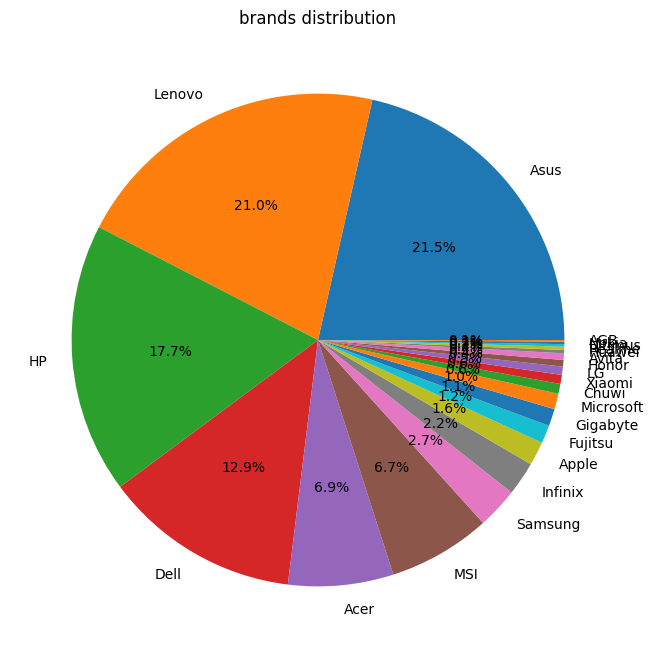

In [37]:
brand_counts=data['brand'].value_counts()
plt.figure(figsize=(10,8))
plt.pie(brand_counts,labels=brand_counts.index,autopct='%1.1f%%')
plt.title("brands distribution")
plt.show()


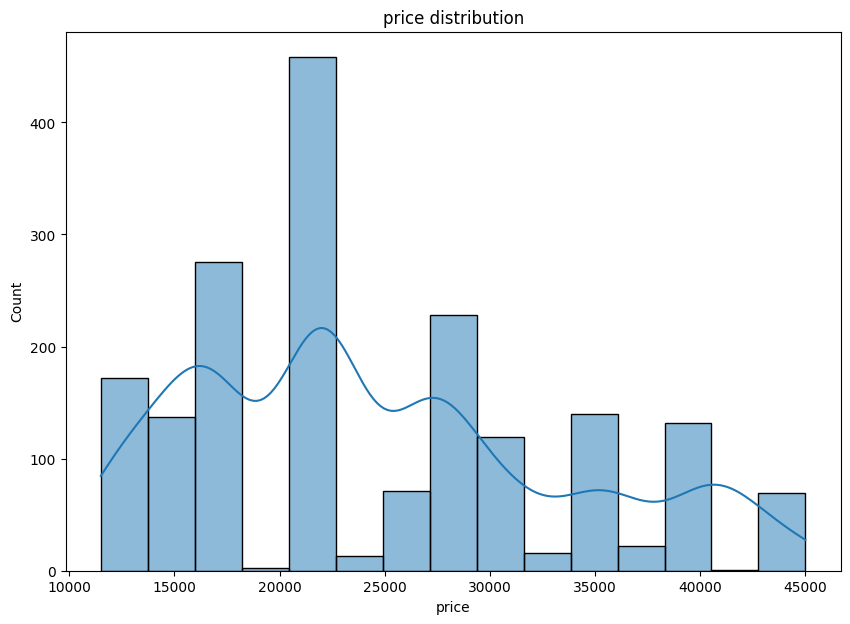

In [38]:
plt.figure(figsize=(10,7))
sns.histplot(data['price'],kde=True)
plt.title("price distribution")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

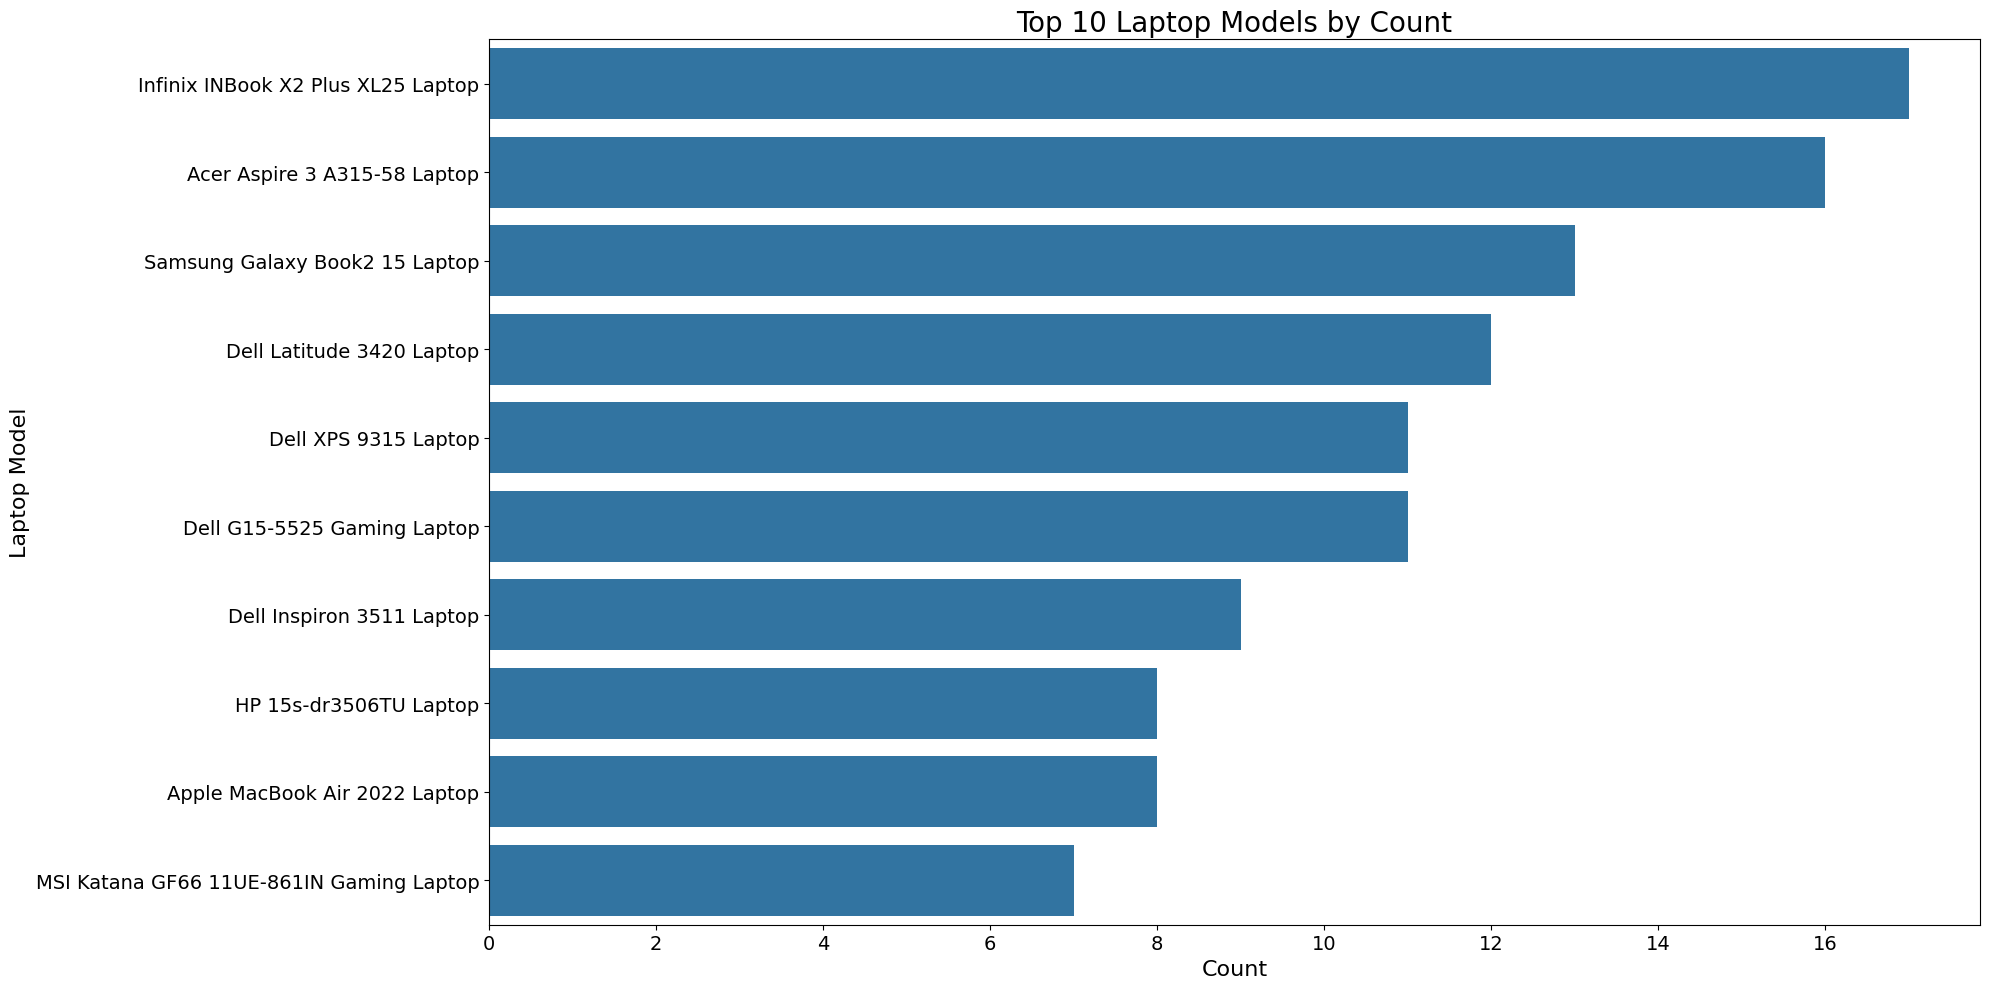

In [39]:
laptop_counts = data['model_name'].value_counts().head(10)

plt.figure(figsize=(20, 10))
sns.barplot(
    x=laptop_counts.values,
    y=laptop_counts.index
)

plt.xlabel("Count", fontsize=16)
plt.ylabel("Laptop Model", fontsize=16)
plt.title("Top 10 Laptop Models by Count", fontsize=20)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.show

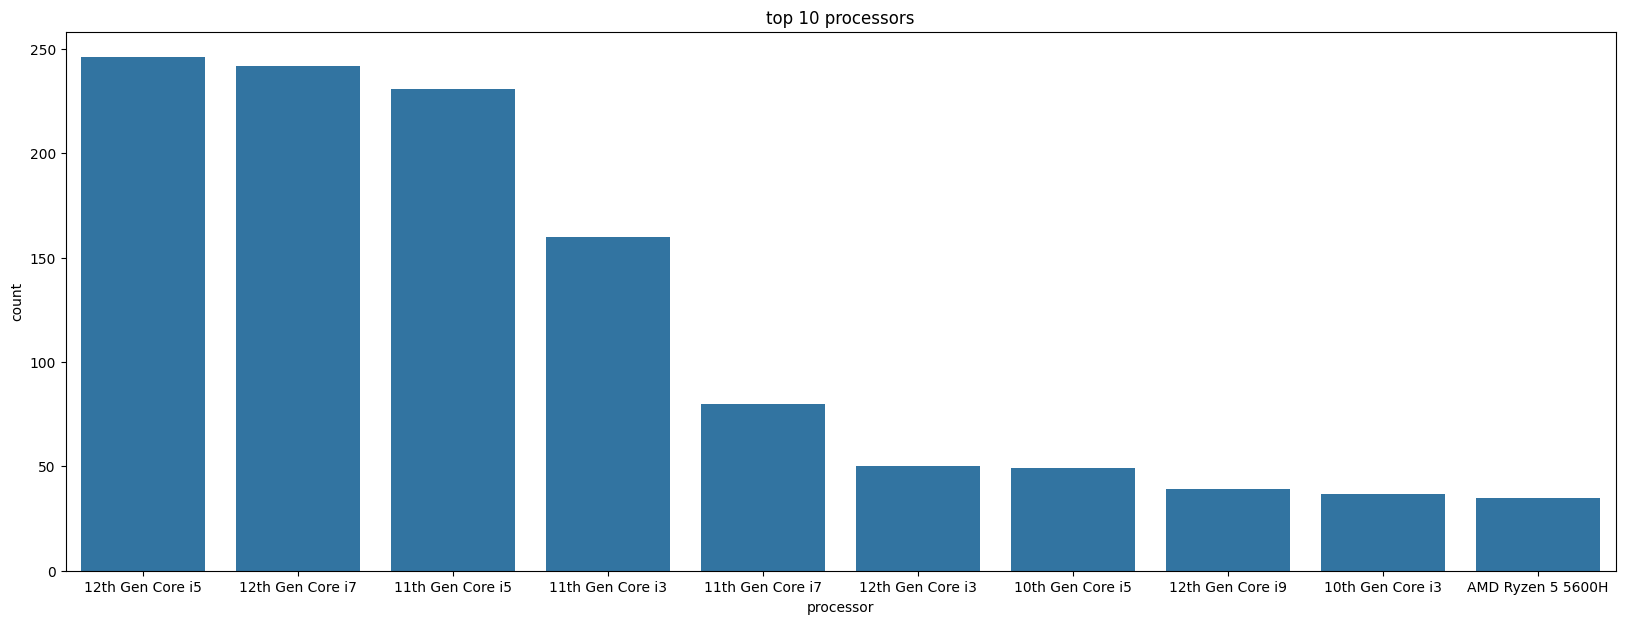

In [40]:
processor_count=data['processor_name'].value_counts().head(10)
plt.figure(figsize=(20,7))
sns.barplot(x=processor_count.index,y=processor_count.values)
plt.xlabel("processor")
plt.ylabel("count")
plt.title("top 10 processors")
plt.show()

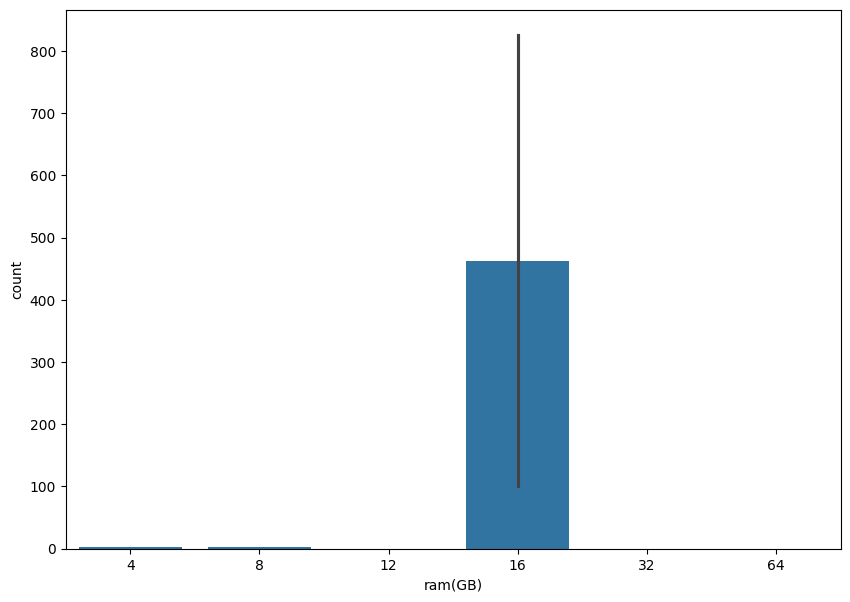

In [41]:
plt.figure(figsize=(10,7))
sns.barplot(x=data['ram(GB)'],y=data['ram(GB)'].value_counts())
plt.show()

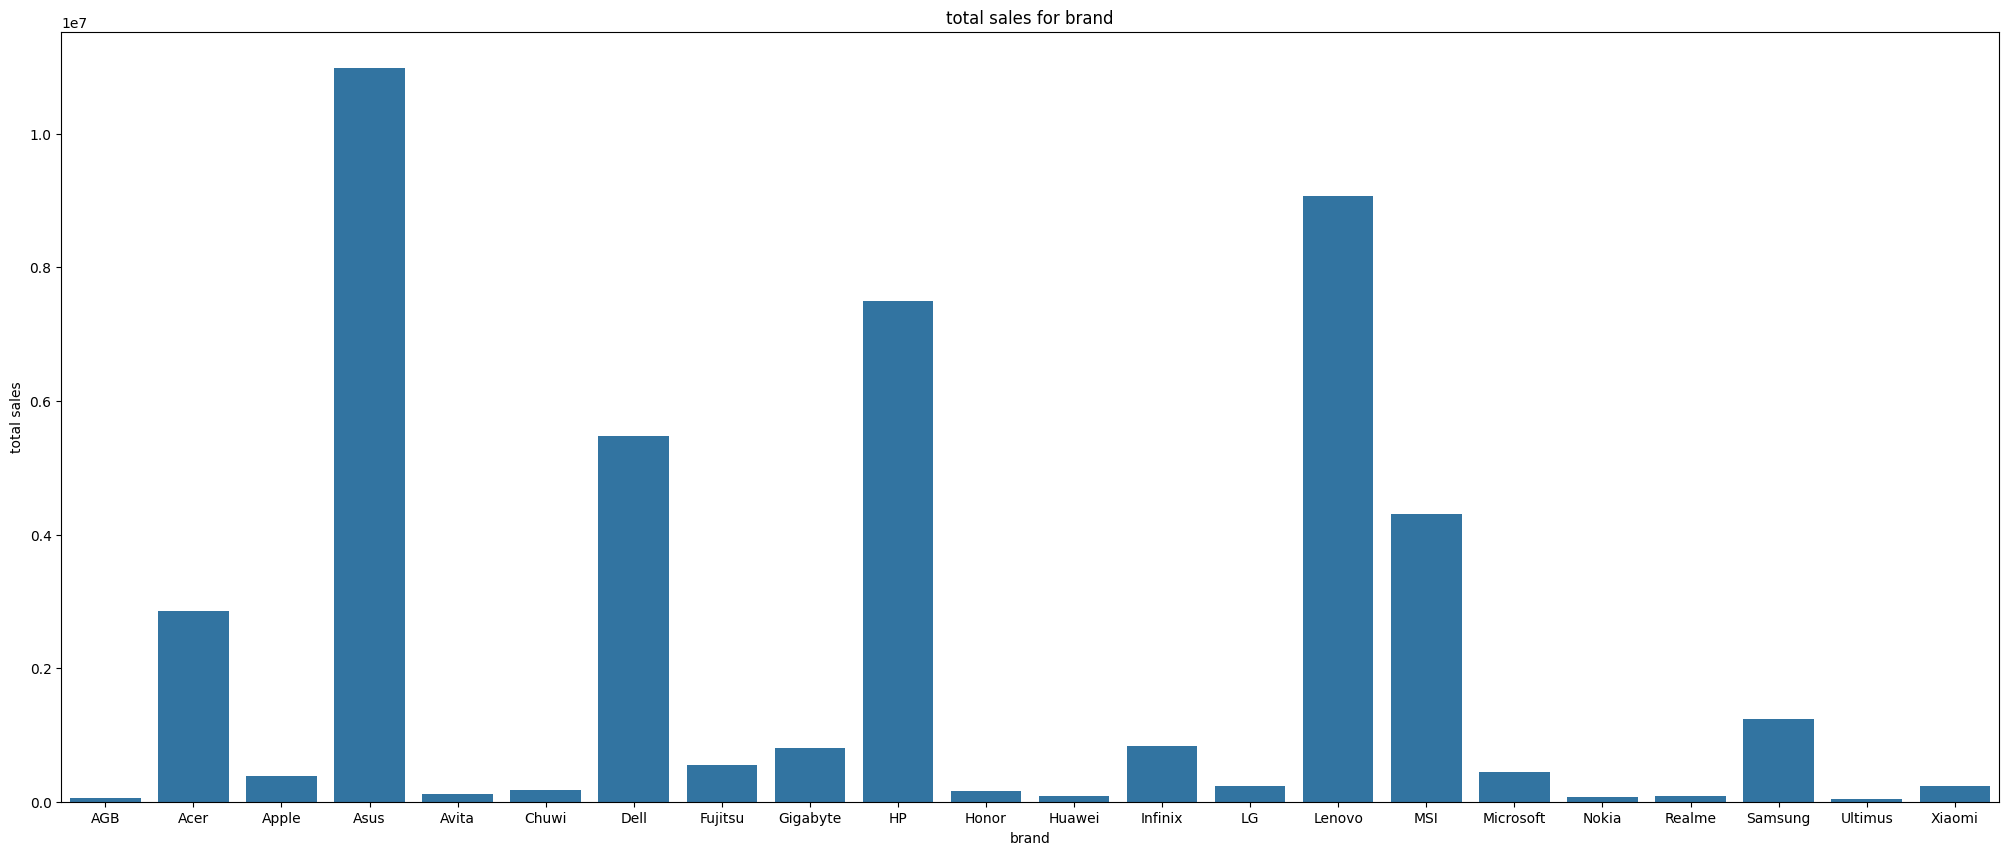

In [42]:
total_sales=data.groupby('brand')['price'].sum()
plt.figure(figsize=(25,10))
sns.barplot(x=total_sales.index,y=total_sales.values)
plt.xlabel("brand")
plt.ylabel("total sales")
plt.title("total sales for brand")
plt.show()

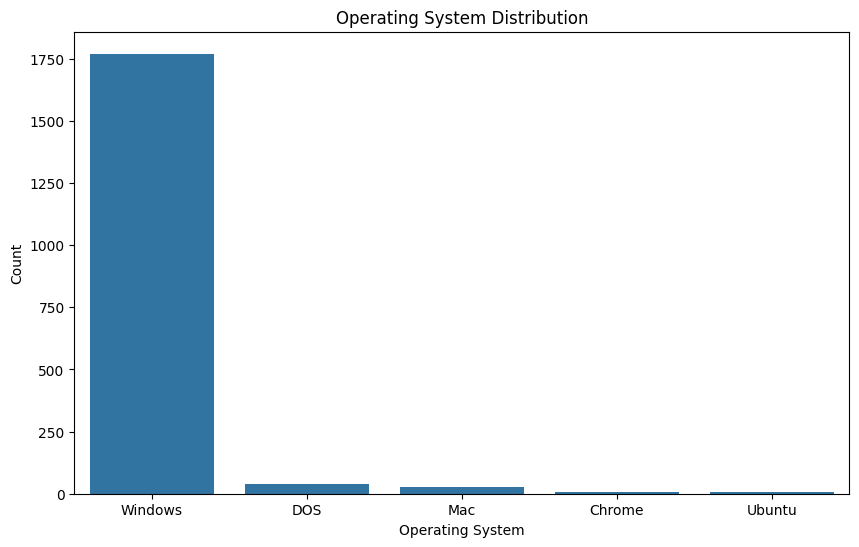

In [43]:
operating_system_counts = data['Operating System'].value_counts()

plt.figure(figsize=(10,6))
sns.barplot(
    x=operating_system_counts.index,
    y=operating_system_counts.values
)
plt.xlabel("Operating System")
plt.ylabel("Count")
plt.title("Operating System Distribution")
plt.show()

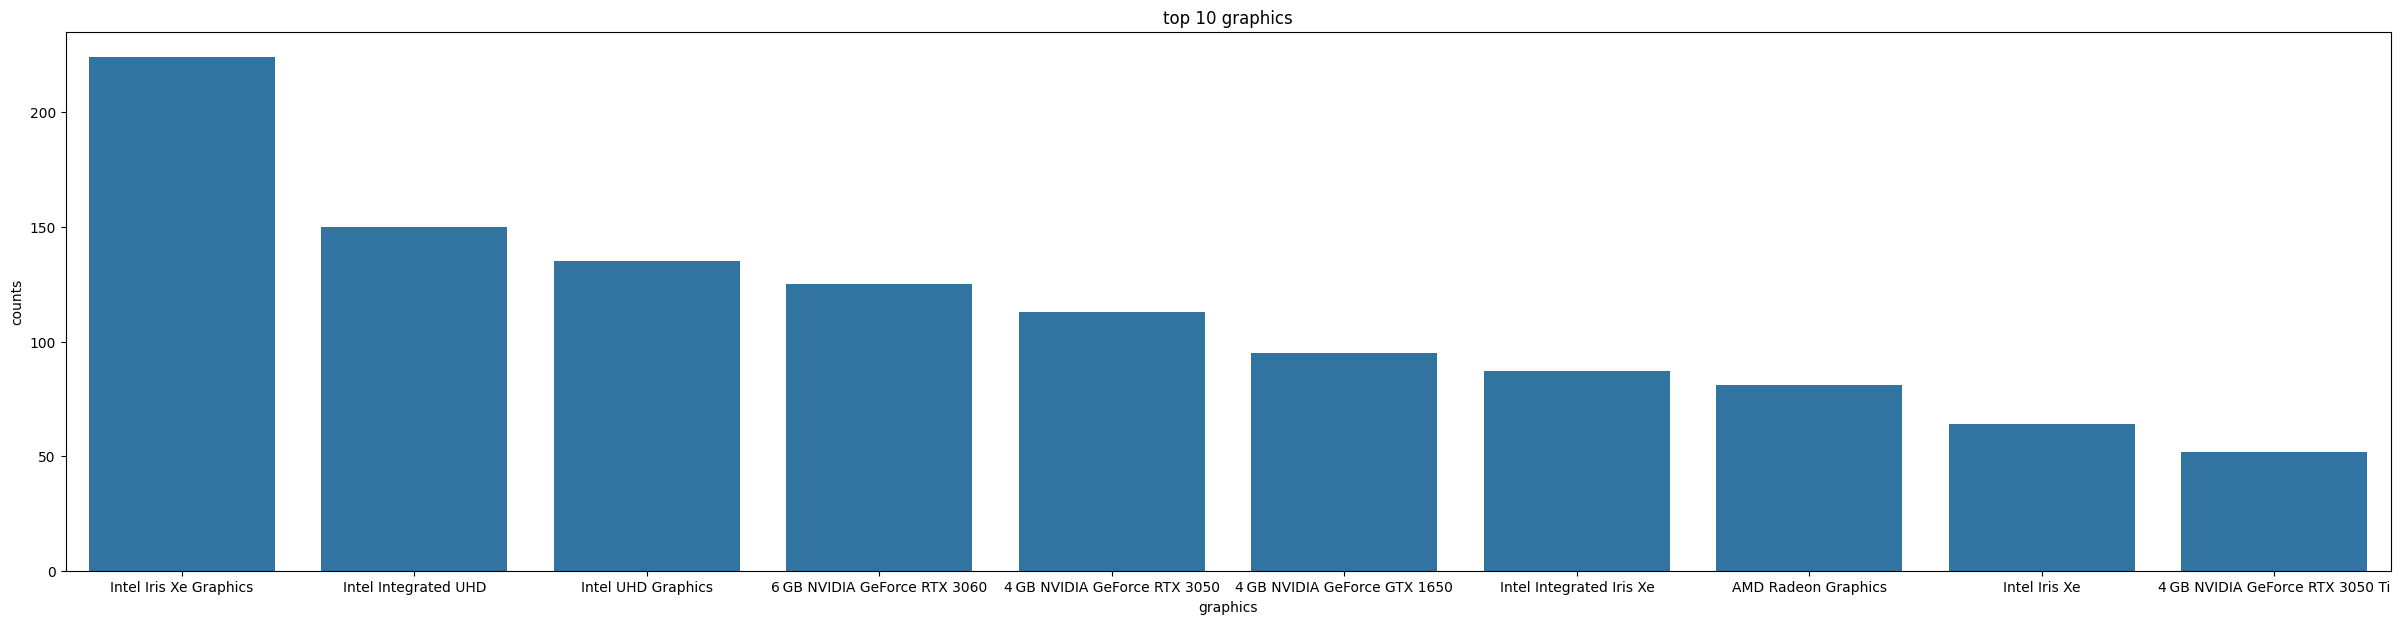

In [44]:
graphics_counts=data['graphics'].value_counts().head(10)
plt.figure(figsize=(30,7))
sns.barplot(x=graphics_counts.index,y=graphics_counts.values)
plt.xlabel("graphics")
plt.ylabel("counts")
plt.title("top 10 graphics")
plt.show()

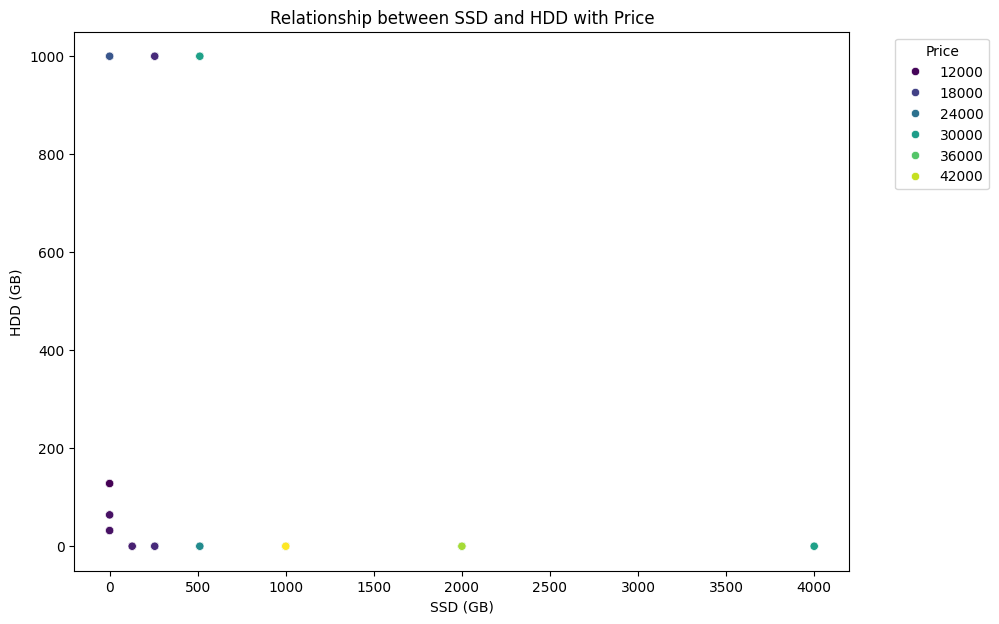

In [45]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    x='ssd(GB)',
    y='Hard Disk(GB)',
    hue='price',
    palette='viridis',
    data=data
)
plt.xlabel("SSD (GB)")
plt.ylabel("HDD (GB)")
plt.title("Relationship between SSD and HDD with Price")
plt.legend(title="Price", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [46]:
data.head()

,Date,Quantity,model_name,brand,processor_name,ram(GB),ssd(GB),Hard Disk(GB),Operating System,graphics,screen_size(inches),resolution (pixels),no_of_cores,no_of_threads,spec_score,price,laptop_user
0,2023-01-01,1,Samsung Galaxy Book 3 Pro 360 NP960QFG-KA3IN L...,Samsung,13th Gen Core i7,16,1000,0,Windows,Intel Iris Xe Graphics,16.0,2880 x 1800,12,16,82,27300,Gamer
1,2023-01-01,1,HP 15s-du3519TX Laptop,HP,11th Gen Core i5,8,512,0,Windows,2 GB NVIDIA GeForce MX450,15.6,1920 x 1080,4,8,62,21500,Normal
2,2023-01-01,1,Lenovo Yoga 9i 82BG005JIN Laptop,Lenovo,11th Gen Core i7,16,1000,0,Windows,Intel Iris Xe Graphics,14.0,3840 x 2160,4,8,67,27300,Gamer
3,2023-01-01,1,Lenovo E41-55 82FJ00ALIH Laptop,Lenovo,Athlon 3150U,4,0,1000,DOS,AMD Radeon AMD,14.0,1366 x 768,2,2,48,14000,Normal
4,2023-01-02,1,Lenovo IdeaPad Slim 5 82FG01HAIN Laptop,Lenovo,11th Gen Core i5,16,512,0,Windows,Intel Iris Xe Graphics,15.6,1920 x 1080,4,8,53,22300,Gamer


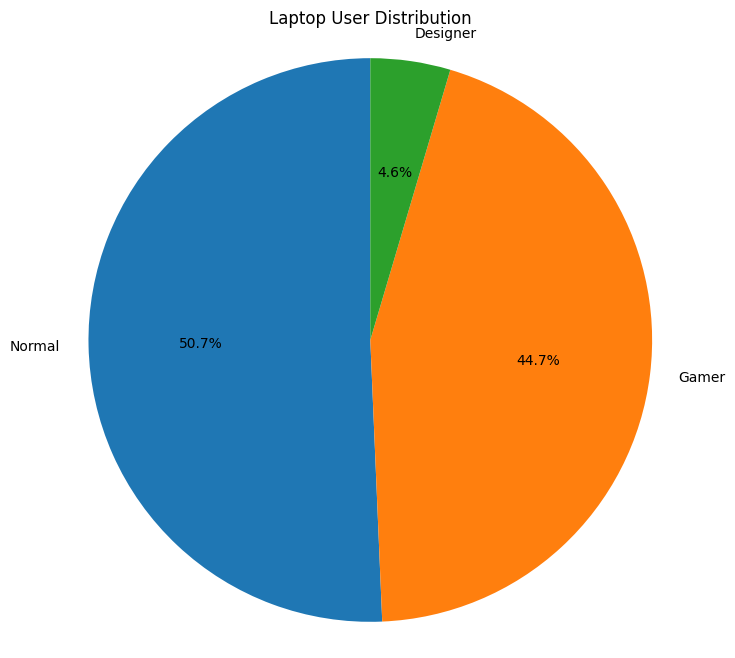

In [47]:

laptop_user_counts = data['laptop_user'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(
    laptop_user_counts,
    labels=laptop_user_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Laptop User Distribution")
plt.axis('equal')  # عشان الدايرة تطلع مظبوطة
plt.show()


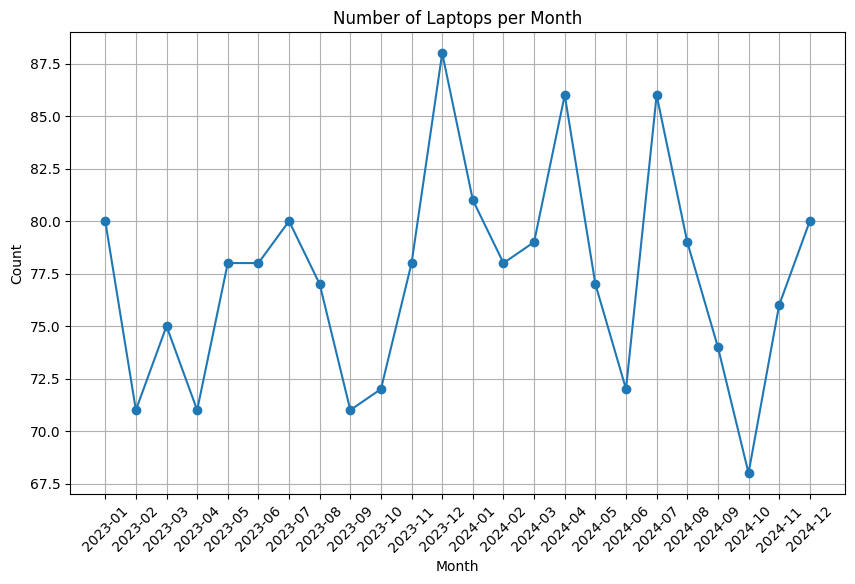

In [48]:
data['Date'] = pd.to_datetime(data['Date'])

# 2️⃣ إنشاء عمود الشهر
data['Month'] = data['Date'].dt.to_period('M')

# ===============================
# 🔹 Line Chart (عدد اللابتوبات كل شهر)
# ===============================
monthly_count = data.groupby('Month').size()

plt.figure(figsize=(10,6))
plt.plot(
    monthly_count.index.astype(str),
    monthly_count.values,
    marker='o'
)
plt.xlabel("Month")
plt.ylabel("Count")
plt.title("Number of Laptops per Month")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

Encoding

In [49]:
data.head()

,Date,Quantity,model_name,brand,processor_name,ram(GB),ssd(GB),Hard Disk(GB),Operating System,graphics,screen_size(inches),resolution (pixels),no_of_cores,no_of_threads,spec_score,price,laptop_user,Month
0,2023-01-01,1,Samsung Galaxy Book 3 Pro 360 NP960QFG-KA3IN L...,Samsung,13th Gen Core i7,16,1000,0,Windows,Intel Iris Xe Graphics,16.0,2880 x 1800,12,16,82,27300,Gamer,2023-01
1,2023-01-01,1,HP 15s-du3519TX Laptop,HP,11th Gen Core i5,8,512,0,Windows,2 GB NVIDIA GeForce MX450,15.6,1920 x 1080,4,8,62,21500,Normal,2023-01
2,2023-01-01,1,Lenovo Yoga 9i 82BG005JIN Laptop,Lenovo,11th Gen Core i7,16,1000,0,Windows,Intel Iris Xe Graphics,14.0,3840 x 2160,4,8,67,27300,Gamer,2023-01
3,2023-01-01,1,Lenovo E41-55 82FJ00ALIH Laptop,Lenovo,Athlon 3150U,4,0,1000,DOS,AMD Radeon AMD,14.0,1366 x 768,2,2,48,14000,Normal,2023-01
4,2023-01-02,1,Lenovo IdeaPad Slim 5 82FG01HAIN Laptop,Lenovo,11th Gen Core i5,16,512,0,Windows,Intel Iris Xe Graphics,15.6,1920 x 1080,4,8,53,22300,Gamer,2023-01


In [50]:
cols_to_drop = ["Date", "Quantity", "model_name"]
data.drop(columns=cols_to_drop, inplace=True)

In [51]:
data.columns

Index(['brand', 'processor_name', 'ram(GB)', 'ssd(GB)', 'Hard Disk(GB)',
       'Operating System', 'graphics', 'screen_size(inches)',
       'resolution (pixels)', 'no_of_cores', 'no_of_threads', 'spec_score',
       'price', 'laptop_user', 'Month'],
      dtype='object')

In [52]:
data_copy = data.copy()

graphics

In [53]:
data['graphics'].unique()

array(['Intel Iris Xe Graphics', '2\u2009GB NVIDIA GeForce MX450',
       'AMD Radeon AMD', 'Intel Integrated UHD', 'Intel UHD Graphics',
       '6\u2009GB NVIDIA GeForce RTX 3060',
       '4\u2009GB NVIDIA GeForce RTX 3050Ti',
       '8\u2009GB NVIDIA GeForce RTX 3070 Ti',
       '4\u2009GB NVIDIA GeForce RTX 3050', 'Intel Integrated',
       'Intel Integrated UHD Graphics', 'Intel Iris XE Graphics',
       '2\u2009GB NVIDIA MX450',
       '4\u2009GB \u200eNVIDIA GeForce RTX 3050 Ti', '10 Core GPU',
       '4\u2009GB Nvidia RTX 3050 Ti', 'AMD Radeon Graphics',
       '4\u2009GB NVIDIA GeForce GTX 1650', 'Intel Iris Xe',
       'Intel Integrated Iris Xe', 'AMD Raedon Graphics',
       'Intel Integrated Iris Xe Graphics',
       '4\u2009GB AMD Radeon RX5500M',
       '4\u2009GB NVIDIA GeForce GTX GTX-1650', 'Intel Irix Xe Graphics',
       '6\u2009GB Nvidia RTX 3060',
       '4\u2009GB NVIDIA GeForce GTX 1650 Max-Q',
       '8\u2009GB NVIDIA GeForce RTX 3070Ti',
       '4\u2009GB NVIDIA

In [54]:
data["graphics_clean"] = (
    data["graphics"]
    .astype(str)
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
)

In [55]:
data["graphics_clean"]

0              intel iris xe graphics
1           2 gb nvidia geforce mx450
2              intel iris xe graphics
3                      amd radeon amd
4              intel iris xe graphics
                    ...              
1863     4 gb nvidia geforce rtx 3050
1864           intel iris xe graphics
1865                    intel iris xe
1866     4 gb nvidia geforce gtx 1650
1867    intel integrated uhd graphics
Name: graphics_clean, Length: 1855, dtype: object

In [56]:
data.head()

,brand,processor_name,ram(GB),ssd(GB),Hard Disk(GB),Operating System,graphics,screen_size(inches),resolution (pixels),no_of_cores,no_of_threads,spec_score,price,laptop_user,Month,graphics_clean
0,Samsung,13th Gen Core i7,16,1000,0,Windows,Intel Iris Xe Graphics,16.0,2880 x 1800,12,16,82,27300,Gamer,2023-01,intel iris xe graphics
1,HP,11th Gen Core i5,8,512,0,Windows,2 GB NVIDIA GeForce MX450,15.6,1920 x 1080,4,8,62,21500,Normal,2023-01,2 gb nvidia geforce mx450
2,Lenovo,11th Gen Core i7,16,1000,0,Windows,Intel Iris Xe Graphics,14.0,3840 x 2160,4,8,67,27300,Gamer,2023-01,intel iris xe graphics
3,Lenovo,Athlon 3150U,4,0,1000,DOS,AMD Radeon AMD,14.0,1366 x 768,2,2,48,14000,Normal,2023-01,amd radeon amd
4,Lenovo,11th Gen Core i5,16,512,0,Windows,Intel Iris Xe Graphics,15.6,1920 x 1080,4,8,53,22300,Gamer,2023-01,intel iris xe graphics


In [57]:
def gpu_score(gpu):
    g = str(gpu).lower()

    # AMD Integrated
    if "680m" in g:
        return 1

    # High End
    elif (
        "rtx 3080" in g
        or "rtx 3070" in g
        or "rx 6800m" in g
        or "rx 6800s" in g
    ):
        return 5

    # Upper Mid
    elif (
        "rtx 3060" in g
        or "rx 6700" in g
    ):
        return 4

    # Mid
    elif (
        "rtx 3050" in g
        or "a2000" in g
        or "rx 6600" in g
        or "rx 6650" in g
    ):
        return 3

    # Lower Mid
    elif (
        "gtx" in g
        or "mx" in g
        or "rx 5500" in g
    ):
        return 2

    # Integrated
    elif (
        "integrated" in g
        or "iris" in g
        or "uhd" in g
        or "vega" in g
    ):
        return 1

    return 0
data["GPU_Score"] = data["graphics"].apply(gpu_score)

In [58]:
data[["graphics", "GPU_Score"]].value_counts().head(15)

graphics                         GPU_Score
Intel Iris Xe Graphics           1            224
Intel Integrated UHD             1            150
Intel UHD Graphics               1            135
6 GB NVIDIA GeForce RTX 3060     4            125
4 GB NVIDIA GeForce RTX 3050     3            113
4 GB NVIDIA GeForce GTX 1650     2             95
Intel Integrated Iris Xe         1             87
AMD Radeon Graphics              0             81
Intel Iris Xe                    1             64
4 GB NVIDIA GeForce RTX 3050 Ti  3             52
AMD Radeon AMD                   0             49
AMD Radeon                       0             44
Intel Integrated UHD Graphics    1             35
Intel Integrated                 1             29
Intel Iris X Graphics            1             26
Name: count, dtype: int64

In [59]:
import re

def extract_vram(gpu):
    g = str(gpu).lower()
    match = re.search(r'(\d+)\s*gb', g)
    if match:
        return int(match.group(1))
    return 0

data["VRAM_GB"] = data["graphics"].apply(extract_vram)

In [60]:
data[["graphics", "VRAM_GB"]].value_counts().head(15)

graphics                         VRAM_GB
Intel Iris Xe Graphics           0          224
Intel Integrated UHD             0          150
Intel UHD Graphics               0          135
6 GB NVIDIA GeForce RTX 3060     6          125
4 GB NVIDIA GeForce RTX 3050     4          113
4 GB NVIDIA GeForce GTX 1650     4           95
Intel Integrated Iris Xe         0           87
AMD Radeon Graphics              0           81
Intel Iris Xe                    0           64
4 GB NVIDIA GeForce RTX 3050 Ti  4           52
AMD Radeon AMD                   0           49
AMD Radeon                       0           44
Intel Integrated UHD Graphics    0           35
Intel Integrated                 0           29
Intel Iris X Graphics            0           26
Name: count, dtype: int64

In [61]:
data.drop(columns=["graphics",'Month'], inplace=True)

In [62]:
data.columns

Index(['brand', 'processor_name', 'ram(GB)', 'ssd(GB)', 'Hard Disk(GB)',
       'Operating System', 'screen_size(inches)', 'resolution (pixels)',
       'no_of_cores', 'no_of_threads', 'spec_score', 'price', 'laptop_user',
       'graphics_clean', 'GPU_Score', 'VRAM_GB'],
      dtype='object')

CPU_BRAND

In [63]:
def extract_cpu_brand(cpu):
    c = str(cpu).lower()

    if "intel" in c or "i3" in c or "i5" in c or "i7" in c or "i9" in c:
        return "Intel"

    elif "ryzen" in c or "athlon" in c:
        return "AMD"

    elif "m1" in c or "m2" in c:
        return "Apple"

    return "Other"
data["CPU_Brand"] = data["processor_name"].apply(extract_cpu_brand)

In [64]:
data["CPU_Brand"].value_counts()

CPU_Brand
Intel    1226
AMD       523
Other      77
Apple      29
Name: count, dtype: int64

In [65]:
data = pd.get_dummies(
    data,
    columns=["CPU_Brand"],
    dtype=int
)

Processor

In [66]:
data['processor_name'].unique()

array(['13th Gen Core i7', '11th Gen Core i5', '11th Gen Core i7',
       'Athlon 3150U', '10th Gen Core i5', '11th Gen Core i3',
       '12th Gen Core i9', ' Celeron N5100', 'AMD Ryzen 7 6800H',
       'AMD Ryzen 9 6900HX', '10th Gen Core i3', '12th Gen Core i7',
       'Celeron N4500', '12th Gen Core i5', 'Apple M2',
       'AMD Ryzen 5 5500U', 'Pentium N5030', 'Ryzen 9 5900HX',
       'AMD Ryzen 3 5425U', 'Intel Core i5', 'Ryzen 5 5625U',
       'AMD Ryzen 3 5300U', 'Ryzen 7 6800H', 'Ryzen 7 5700U',
       '12th Gen Core i3', '11th Gen Core i9', 'AMD Ryzen 5-5500U',
       'AMD Ryzen 3 3250U', 'Ryzen 5 5600H', 'Athlon Pro 3045B',
       'AMD Ryzen 5 5600H', 'AMD Ryzen 3  3250U', 'Ryzen 5-5625U',
       'AMD Ryzen 9 6900HS', 'Ryzen 7 5800H ', 'Ryzen 3 5300U',
       'AMD Ryzen 5 6600H', 'Ryzen 5 5500U', 'AMD Ryzen 7 5800H',
       'Intel Celeron N4020', 'AMD Ryzen 5 4500U', 'Celeron N4020',
       'Ryzen 7 5800H', 'AMD Ryzen 7 6800HS ', 'AMD Ryzen 7-5800H',
       'Pentium Silver N60

In [67]:
def extract_cpu_generation(cpu):
    c = str(cpu).lower()
    for gen in ["13th", "12th", "11th", "10th"]:
        if gen in c:
            return int(gen.replace("th", ""))
    return 0

data["CPU_Generation"] = data["processor_name"].apply(extract_cpu_generation)

In [68]:
data[["processor_name", "CPU_Generation"]].head(20)

,processor_name,CPU_Generation
0,13th Gen Core i7,13
1,11th Gen Core i5,11
2,11th Gen Core i7,11
3,Athlon 3150U,0
4,11th Gen Core i5,11
5,10th Gen Core i5,10
6,11th Gen Core i3,11
7,11th Gen Core i5,11
8,13th Gen Core i7,13
9,13th Gen Core i7,13


In [69]:
def extract_cpu_class(cpu):
    c = str(cpu).lower()
    
    # Apple
    if "m2 max" in c:
        return 5
    elif "m2" in c:
        return 4
    elif "m1" in c:
        return 3
    
    # Intel Core
    if "i9" in c:
        return 5
    elif "i7" in c:
        return 4
    elif "i5" in c:
        return 3
    elif "i3" in c:
        return 2
    
    # AMD Ryzen
    if "ryzen 9" in c:
        return 5
    elif "ryzen 7" in c:
        return 4
    elif "ryzen 5" in c:
        return 3
    elif "ryzen 3" in c:
        return 2
    
    # Low-end CPUs
    if (
        "celeron" in c
        or "pentium" in c
        or "athlon" in c
        or "snapdragon" in c
    ):
        return 1
    
    return 0

data["CPU_Class"] = data["processor_name"].apply(extract_cpu_class)

In [70]:
data[["processor_name", "CPU_Generation", "CPU_Class"]].head(25)

,processor_name,CPU_Generation,CPU_Class
0,13th Gen Core i7,13,4
1,11th Gen Core i5,11,3
2,11th Gen Core i7,11,4
3,Athlon 3150U,0,1
4,11th Gen Core i5,11,3
5,10th Gen Core i5,10,3
6,11th Gen Core i3,11,2
7,11th Gen Core i5,11,3
8,13th Gen Core i7,13,4
9,13th Gen Core i7,13,4


In [71]:
data

,brand,processor_name,ram(GB),ssd(GB),Hard Disk(GB),Operating System,screen_size(inches),resolution (pixels),no_of_cores,no_of_threads,...,laptop_user,graphics_clean,GPU_Score,VRAM_GB,CPU_Brand_AMD,CPU_Brand_Apple,CPU_Brand_Intel,CPU_Brand_Other,CPU_Generation,CPU_Class
0,Samsung,13th Gen Core i7,16,1000,0,Windows,16.0,2880 x 1800,12,16,...,Gamer,intel iris xe graphics,1,0,0,0,1,0,13,4
1,HP,11th Gen Core i5,8,512,0,Windows,15.6,1920 x 1080,4,8,...,Normal,2 gb nvidia geforce mx450,2,2,0,0,1,0,11,3
2,Lenovo,11th Gen Core i7,16,1000,0,Windows,14.0,3840 x 2160,4,8,...,Gamer,intel iris xe graphics,1,0,0,0,1,0,11,4
3,Lenovo,Athlon 3150U,4,0,1000,DOS,14.0,1366 x 768,2,2,...,Normal,amd radeon amd,0,0,1,0,0,0,0,1
4,Lenovo,11th Gen Core i5,16,512,0,Windows,15.6,1920 x 1080,4,8,...,Gamer,intel iris xe graphics,1,0,0,0,1,0,11,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1863,Lenovo,11th Gen Core i5,8,512,0,Windows,15.6,1920 x 1080,4,8,...,Normal,4 gb nvidia geforce rtx 3050,3,4,0,0,1,0,11,3
1864,Lenovo,11th Gen Core i5,16,512,0,Windows,14.0,1920 x 1080,4,8,...,Gamer,intel iris xe graphics,1,0,0,0,1,0,11,3
1865,Lenovo,12th Gen Core i5,8,512,0,Windows,14.0,1920 x 1080,10,12,...,Normal,intel iris xe,1,0,0,0,1,0,12,3
1866,Asus,AMD Ryzen 5 4600H,8,512,0,Windows,15.6,1920 x 1080,6,12,...,Normal,4 gb nvidia geforce gtx 1650,2,4,1,0,0,0,0,3


In [72]:
data.drop(columns=["processor_name","graphics_clean"], inplace=True)

In [73]:
data.columns

Index(['brand', 'ram(GB)', 'ssd(GB)', 'Hard Disk(GB)', 'Operating System',
       'screen_size(inches)', 'resolution (pixels)', 'no_of_cores',
       'no_of_threads', 'spec_score', 'price', 'laptop_user', 'GPU_Score',
       'VRAM_GB', 'CPU_Brand_AMD', 'CPU_Brand_Apple', 'CPU_Brand_Intel',
       'CPU_Brand_Other', 'CPU_Generation', 'CPU_Class'],
      dtype='object')

brand

In [74]:
data["brand"].unique()

array(['Samsung', 'HP', 'Lenovo', 'Asus', 'Dell', 'Infinix', 'Fujitsu',
       'Apple', 'MSI', 'Xiaomi', 'Acer', 'Microsoft', 'Chuwi', 'Ultimus',
       'Gigabyte', 'Nokia', 'LG', 'Realme', 'Avita', 'AGB', 'Honor',
       'Huawei'], dtype=object)

In [75]:
brand_dummies = pd.get_dummies(data["brand"], prefix="brand")
data = pd.concat([data, brand_dummies], axis=1)

In [76]:
brand_dummies.head()

,brand_AGB,brand_Acer,brand_Apple,brand_Asus,brand_Avita,brand_Chuwi,brand_Dell,brand_Fujitsu,brand_Gigabyte,brand_HP,...,brand_Infinix,brand_LG,brand_Lenovo,brand_MSI,brand_Microsoft,brand_Nokia,brand_Realme,brand_Samsung,brand_Ultimus,brand_Xiaomi
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False


In [77]:
data.columns

Index(['brand', 'ram(GB)', 'ssd(GB)', 'Hard Disk(GB)', 'Operating System',
       'screen_size(inches)', 'resolution (pixels)', 'no_of_cores',
       'no_of_threads', 'spec_score', 'price', 'laptop_user', 'GPU_Score',
       'VRAM_GB', 'CPU_Brand_AMD', 'CPU_Brand_Apple', 'CPU_Brand_Intel',
       'CPU_Brand_Other', 'CPU_Generation', 'CPU_Class', 'brand_AGB',
       'brand_Acer', 'brand_Apple', 'brand_Asus', 'brand_Avita', 'brand_Chuwi',
       'brand_Dell', 'brand_Fujitsu', 'brand_Gigabyte', 'brand_HP',
       'brand_Honor', 'brand_Huawei', 'brand_Infinix', 'brand_LG',
       'brand_Lenovo', 'brand_MSI', 'brand_Microsoft', 'brand_Nokia',
       'brand_Realme', 'brand_Samsung', 'brand_Ultimus', 'brand_Xiaomi'],
      dtype='object')

opearation_system(windows)


In [78]:
data['Operating System'].unique()

array(['Windows', 'DOS', 'Mac', 'Chrome', 'Ubuntu'], dtype=object)

In [79]:
os_dummies = pd.get_dummies(data["Operating System"], prefix="os")
data = pd.concat([data, os_dummies], axis=1)

In [80]:
data.filter(like="os_").head()

,os_Chrome,os_DOS,os_Mac,os_Ubuntu,os_Windows
0,False,False,False,False,True
1,False,False,False,False,True
2,False,False,False,False,True
3,False,True,False,False,False
4,False,False,False,False,True


In [81]:
data.drop(columns=["brand", "Operating System","laptop_user"], inplace=True, errors="ignore")

In [82]:
data.columns

Index(['ram(GB)', 'ssd(GB)', 'Hard Disk(GB)', 'screen_size(inches)',
       'resolution (pixels)', 'no_of_cores', 'no_of_threads', 'spec_score',
       'price', 'GPU_Score', 'VRAM_GB', 'CPU_Brand_AMD', 'CPU_Brand_Apple',
       'CPU_Brand_Intel', 'CPU_Brand_Other', 'CPU_Generation', 'CPU_Class',
       'brand_AGB', 'brand_Acer', 'brand_Apple', 'brand_Asus', 'brand_Avita',
       'brand_Chuwi', 'brand_Dell', 'brand_Fujitsu', 'brand_Gigabyte',
       'brand_HP', 'brand_Honor', 'brand_Huawei', 'brand_Infinix', 'brand_LG',
       'brand_Lenovo', 'brand_MSI', 'brand_Microsoft', 'brand_Nokia',
       'brand_Realme', 'brand_Samsung', 'brand_Ultimus', 'brand_Xiaomi',
       'os_Chrome', 'os_DOS', 'os_Mac', 'os_Ubuntu', 'os_Windows'],
      dtype='object')

In [83]:
data.drop(columns=["resolution (pixels)"], inplace=True, errors="ignore")


In [84]:
data.columns

Index(['ram(GB)', 'ssd(GB)', 'Hard Disk(GB)', 'screen_size(inches)',
       'no_of_cores', 'no_of_threads', 'spec_score', 'price', 'GPU_Score',
       'VRAM_GB', 'CPU_Brand_AMD', 'CPU_Brand_Apple', 'CPU_Brand_Intel',
       'CPU_Brand_Other', 'CPU_Generation', 'CPU_Class', 'brand_AGB',
       'brand_Acer', 'brand_Apple', 'brand_Asus', 'brand_Avita', 'brand_Chuwi',
       'brand_Dell', 'brand_Fujitsu', 'brand_Gigabyte', 'brand_HP',
       'brand_Honor', 'brand_Huawei', 'brand_Infinix', 'brand_LG',
       'brand_Lenovo', 'brand_MSI', 'brand_Microsoft', 'brand_Nokia',
       'brand_Realme', 'brand_Samsung', 'brand_Ultimus', 'brand_Xiaomi',
       'os_Chrome', 'os_DOS', 'os_Mac', 'os_Ubuntu', 'os_Windows'],
      dtype='object')

In [85]:
corr_matrix = data.corr()
corr_matrix["price"].sort_values(ascending=False)



price                  1.000000
GPU_Score              0.815073
no_of_threads          0.784172
CPU_Class              0.744997
VRAM_GB                0.737945
spec_score             0.729903
no_of_cores            0.600822
ssd(GB)                0.580363
ram(GB)                0.570312
screen_size(inches)    0.420568
brand_MSI              0.302314
os_Windows             0.244512
brand_Asus             0.176412
brand_Gigabyte         0.164369
CPU_Generation         0.147411
CPU_Brand_Intel        0.080544
CPU_Brand_AMD          0.070999
brand_AGB              0.007039
brand_Fujitsu          0.002327
brand_Samsung          0.001722
brand_LG              -0.006794
brand_Nokia           -0.010568
brand_Huawei          -0.015373
brand_Microsoft       -0.016622
brand_Realme          -0.021179
brand_Xiaomi          -0.033673
brand_Honor           -0.035027
brand_Ultimus         -0.053063
os_Ubuntu             -0.066222
brand_Acer            -0.069990
brand_Infinix         -0.074487
brand_De

Remove dublcated rows

In [86]:
data.duplicated().sum()


np.int64(1054)

In [87]:
data = data.drop_duplicates()


In [88]:
data.duplicated().sum()


np.int64(0)

delete spec_score

In [89]:
data.drop(columns=["spec_score"], inplace=True, errors="ignore")


In [90]:
data.columns

Index(['ram(GB)', 'ssd(GB)', 'Hard Disk(GB)', 'screen_size(inches)',
       'no_of_cores', 'no_of_threads', 'price', 'GPU_Score', 'VRAM_GB',
       'CPU_Brand_AMD', 'CPU_Brand_Apple', 'CPU_Brand_Intel',
       'CPU_Brand_Other', 'CPU_Generation', 'CPU_Class', 'brand_AGB',
       'brand_Acer', 'brand_Apple', 'brand_Asus', 'brand_Avita', 'brand_Chuwi',
       'brand_Dell', 'brand_Fujitsu', 'brand_Gigabyte', 'brand_HP',
       'brand_Honor', 'brand_Huawei', 'brand_Infinix', 'brand_LG',
       'brand_Lenovo', 'brand_MSI', 'brand_Microsoft', 'brand_Nokia',
       'brand_Realme', 'brand_Samsung', 'brand_Ultimus', 'brand_Xiaomi',
       'os_Chrome', 'os_DOS', 'os_Mac', 'os_Ubuntu', 'os_Windows'],
      dtype='object')

In [91]:
data.head()

,ram(GB),ssd(GB),Hard Disk(GB),screen_size(inches),no_of_cores,no_of_threads,price,GPU_Score,VRAM_GB,CPU_Brand_AMD,...,brand_Nokia,brand_Realme,brand_Samsung,brand_Ultimus,brand_Xiaomi,os_Chrome,os_DOS,os_Mac,os_Ubuntu,os_Windows
0,16,1000,0,16.0,12,16,27300,1,0,0,...,False,False,True,False,False,False,False,False,False,True
1,8,512,0,15.6,4,8,21500,2,2,0,...,False,False,False,False,False,False,False,False,False,True
2,16,1000,0,14.0,4,8,27300,1,0,0,...,False,False,False,False,False,False,False,False,False,True
3,4,0,1000,14.0,2,2,14000,0,0,1,...,False,False,False,False,False,False,True,False,False,False
4,16,512,0,15.6,4,8,22300,1,0,0,...,False,False,False,False,False,False,False,False,False,True


In [92]:
pd.set_option('display.max_columns', None)
data.head()

,ram(GB),ssd(GB),Hard Disk(GB),screen_size(inches),no_of_cores,no_of_threads,price,GPU_Score,VRAM_GB,CPU_Brand_AMD,CPU_Brand_Apple,CPU_Brand_Intel,CPU_Brand_Other,CPU_Generation,CPU_Class,brand_AGB,brand_Acer,brand_Apple,brand_Asus,brand_Avita,brand_Chuwi,brand_Dell,brand_Fujitsu,brand_Gigabyte,brand_HP,brand_Honor,brand_Huawei,brand_Infinix,brand_LG,brand_Lenovo,brand_MSI,brand_Microsoft,brand_Nokia,brand_Realme,brand_Samsung,brand_Ultimus,brand_Xiaomi,os_Chrome,os_DOS,os_Mac,os_Ubuntu,os_Windows
0,16,1000,0,16.0,12,16,27300,1,0,0,0,1,0,13,4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True
1,8,512,0,15.6,4,8,21500,2,2,0,0,1,0,11,3,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
2,16,1000,0,14.0,4,8,27300,1,0,0,0,1,0,11,4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True
3,4,0,1000,14.0,2,2,14000,0,0,1,0,0,0,0,1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False
4,16,512,0,15.6,4,8,22300,1,0,0,0,1,0,11,3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True


In [93]:
data['CPU_Class'].unique()

array([4, 3, 1, 2, 5, 0])

In [94]:
data['GPU_Score'].unique()

array([1, 2, 0, 4, 3, 5])

In [95]:
data['VRAM_GB'].isna()

0       False
1       False
2       False
3       False
4       False
        ...  
1847    False
1851    False
1854    False
1859    False
1866    False
Name: VRAM_GB, Length: 801, dtype: bool

In [96]:
data.head()

,ram(GB),ssd(GB),Hard Disk(GB),screen_size(inches),no_of_cores,no_of_threads,price,GPU_Score,VRAM_GB,CPU_Brand_AMD,CPU_Brand_Apple,CPU_Brand_Intel,CPU_Brand_Other,CPU_Generation,CPU_Class,brand_AGB,brand_Acer,brand_Apple,brand_Asus,brand_Avita,brand_Chuwi,brand_Dell,brand_Fujitsu,brand_Gigabyte,brand_HP,brand_Honor,brand_Huawei,brand_Infinix,brand_LG,brand_Lenovo,brand_MSI,brand_Microsoft,brand_Nokia,brand_Realme,brand_Samsung,brand_Ultimus,brand_Xiaomi,os_Chrome,os_DOS,os_Mac,os_Ubuntu,os_Windows
0,16,1000,0,16.0,12,16,27300,1,0,0,0,1,0,13,4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True
1,8,512,0,15.6,4,8,21500,2,2,0,0,1,0,11,3,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
2,16,1000,0,14.0,4,8,27300,1,0,0,0,1,0,11,4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True
3,4,0,1000,14.0,2,2,14000,0,0,1,0,0,0,0,1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False
4,16,512,0,15.6,4,8,22300,1,0,0,0,1,0,11,3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True


modify price

In [97]:
mask = (
    (data["CPU_Class"] == 5) &
    (data["GPU_Score"] == 5) &
    (data["ram(GB)"] >= 32) &
    (data["price"] < 35000)
)

data.loc[mask, "price"] = 45000

In [98]:
print(mask.sum())

6


In [99]:
data.loc[mask, [
    "price",
    "CPU_Class",
    "GPU_Score",
    "ram(GB)"
]]  

,price,CPU_Class,GPU_Score,ram(GB)
155,45000,5,5,32
156,45000,5,5,32
403,45000,5,5,32
776,45000,5,5,32
1158,45000,5,5,32
1633,45000,5,5,32


In [100]:
mask2 = (
    (data["CPU_Class"] == 5) &
    (data["GPU_Score"] == 5) &
    (data["ram(GB)"] >= 16) &
    (data["price"] < 35000)
)

data.loc[mask2, "price"] = 43000

In [101]:
print(mask2.sum())


3


In [102]:
data.loc[mask2, [
    "price",
    "CPU_Class",
    "GPU_Score",
    "ram(GB)"
]]  

,price,CPU_Class,GPU_Score,ram(GB)
683,43000,5,5,16
964,43000,5,5,16
1456,43000,5,5,16


In [103]:
data = data[data["VRAM_GB"] <= 12]


In [104]:
mask = (
    (data["CPU_Class"] == 5) &
    (data["VRAM_GB"] >= 8) &
    (data["price"] < 20000)
)

data.loc[mask, "price"] = 43000

In [105]:
mask = (
    (data["CPU_Class"] == 5) &
    (data["VRAM_GB"] >= 6) &
    (data["price"] < 20000)
)

data.loc[mask, "price"] = 41500

In [106]:
data["no_of_cores"] = data.groupby("CPU_Class")["no_of_cores"].transform(
    lambda x: x.replace(0, x[x > 0].median())
)

data["no_of_threads"] = data.groupby("CPU_Class")["no_of_threads"].transform(
    lambda x: x.replace(0, x[x > 0].median())
)

PREDICTION

In [107]:
cols=data.select_dtypes(include='bool').columns
for col in cols:
    data[col]=data[col].astype(int)

In [108]:
data.head()

,ram(GB),ssd(GB),Hard Disk(GB),screen_size(inches),no_of_cores,no_of_threads,price,GPU_Score,VRAM_GB,CPU_Brand_AMD,CPU_Brand_Apple,CPU_Brand_Intel,CPU_Brand_Other,CPU_Generation,CPU_Class,brand_AGB,brand_Acer,brand_Apple,brand_Asus,brand_Avita,brand_Chuwi,brand_Dell,brand_Fujitsu,brand_Gigabyte,brand_HP,brand_Honor,brand_Huawei,brand_Infinix,brand_LG,brand_Lenovo,brand_MSI,brand_Microsoft,brand_Nokia,brand_Realme,brand_Samsung,brand_Ultimus,brand_Xiaomi,os_Chrome,os_DOS,os_Mac,os_Ubuntu,os_Windows
0,16,1000,0,16.0,12,16,27300,1,0,0,0,1,0,13,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1
1,8,512,0,15.6,4,8,21500,2,2,0,0,1,0,11,3,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2,16,1000,0,14.0,4,8,27300,1,0,0,0,1,0,11,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1
3,4,0,1000,14.0,2,2,14000,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0
4,16,512,0,15.6,4,8,22300,1,0,0,0,1,0,11,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1


In [109]:
x=data.drop("price",axis=1)
y=data["price"]

In [110]:
from sklearn.model_selection import train_test_split

In [111]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [112]:
from sklearn.preprocessing import StandardScaler

In [113]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [114]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

In [115]:
models = {

    "Linear regression": LinearRegression(),

    "Decision tree": DecisionTreeRegressor(
        random_state=42
    ),

    "K-nearest Neighbors regression": KNeighborsRegressor(),

    "Random Forest Regression": RandomForestRegressor(
        random_state=42
    )

}

In [116]:
models

{'Linear regression': LinearRegression(),
 'Decision tree': DecisionTreeRegressor(random_state=42),
 'K-nearest Neighbors regression': KNeighborsRegressor(),
 'Random Forest Regression': RandomForestRegressor(random_state=42)}

In [117]:
for name, model in models.items():
    model.fit(x_train_scaled, y_train)
    y_pred = model.predict(x_test_scaled)
    print(name  + " R^2: {:.8f}".format(r2_score(y_test, y_pred)))
    print(name  + " MSE: {:.8f}".format(mean_squared_error(y_test, y_pred)))
    

Linear regression R^2: 0.92781906
Linear regression MSE: 5092827.89010306
Decision tree R^2: 0.97255383
Decision tree MSE: 1936503.26797386
K-nearest Neighbors regression R^2: 0.87760024
K-nearest Neighbors regression MSE: 8636087.39495798
Random Forest Regression R^2: 0.97891911
Random Forest Regression MSE: 1487391.72179364


In [118]:
final_model = RandomForestRegressor(random_state=42)
final_model.fit(x_train_scaled, y_train)
predict=final_model.predict(x_test_scaled)


In [119]:
import joblib

In [120]:
joblib.dump(final_model,"final_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [121]:
predict = final_model.predict(x_test_scaled)

In [122]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predict
})

print(comparison.sample(20))

     Actual     Predicted
27    12500  12590.000000
196   21500  21512.000000
19    22300  22254.666667
195   15500  15500.000000
162   27300  27300.000000
71    25000  26080.000000
28    17500  17500.000000
201   22300  22173.466667
36    27300  27284.000000
58    14000  14880.000000
92    35500  35335.000000
105   16500  16500.000000
234   20500  21292.000000
145   15500  15500.000000
45    22300  22030.990476
90    21500  27267.916667
163   20500  20558.000000
52    40500  40500.000000
3     11500  12145.000000
177   27500  27470.000000


In [123]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import pandas as pd
import numpy as np

results = []

for name, model in models.items():

    model.fit(x_train_scaled, y_train)

    y_pred = model.predict(x_test_scaled)

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)

    results.append([name, r2, mse, rmse, mae])

results_df = pd.DataFrame(
    results,
    columns=["Model", "R²", "MSE", "RMSE", "MAE"]
)

results_df

,Model,R²,MSE,RMSE,MAE
0,Linear regression,0.927819,5.092828e+06,2256.729468,1567.383528
1,Decision tree,0.972554,1.936503e+06,1391.583008,394.257703
2,K-nearest Neighbors regression,0.877600,8.636087e+06,2938.722068,2172.268908
3,Random Forest Regression,0.978919,1.487392e+06,1219.586701,480.692263


Classification


In [124]:
def classify_laptop(row):

    if (
        row['CPU_Class'] >= 4 and
        row['GPU_Score'] >= 4 and
        row['ram(GB)'] >= 16
    ):
        return "High-End"

    elif (
        row['CPU_Class'] >= 3 and
        row['ram(GB)'] >= 8
    ):
        return "Mid-Range"

    else:
        return "Low-End"

In [125]:
data["Category"] = data.apply(classify_laptop, axis=1)

In [126]:
data.head()

,ram(GB),ssd(GB),Hard Disk(GB),screen_size(inches),no_of_cores,no_of_threads,price,GPU_Score,VRAM_GB,CPU_Brand_AMD,CPU_Brand_Apple,CPU_Brand_Intel,CPU_Brand_Other,CPU_Generation,CPU_Class,brand_AGB,brand_Acer,brand_Apple,brand_Asus,brand_Avita,brand_Chuwi,brand_Dell,brand_Fujitsu,brand_Gigabyte,brand_HP,brand_Honor,brand_Huawei,brand_Infinix,brand_LG,brand_Lenovo,brand_MSI,brand_Microsoft,brand_Nokia,brand_Realme,brand_Samsung,brand_Ultimus,brand_Xiaomi,os_Chrome,os_DOS,os_Mac,os_Ubuntu,os_Windows,Category
0,16,1000,0,16.0,12,16,27300,1,0,0,0,1,0,13,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,Mid-Range
1,8,512,0,15.6,4,8,21500,2,2,0,0,1,0,11,3,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,Mid-Range
2,16,1000,0,14.0,4,8,27300,1,0,0,0,1,0,11,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,Mid-Range
3,4,0,1000,14.0,2,2,14000,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,Low-End
4,16,512,0,15.6,4,8,22300,1,0,0,0,1,0,11,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,Mid-Range


In [127]:
print(data["Category"].value_counts())

Category
Mid-Range    503
Low-End      198
High-End      91
Name: count, dtype: int64


In [128]:
data[[
    "CPU_Class",
    "GPU_Score",
    "ram(GB)",
    "Category"
]].head(20)

,CPU_Class,GPU_Score,ram(GB),Category
0,4,1,16,Mid-Range
1,3,2,8,Mid-Range
2,4,1,16,Mid-Range
3,1,0,4,Low-End
4,3,1,16,Mid-Range
5,3,1,8,Mid-Range
6,2,1,8,Low-End
7,3,1,16,Mid-Range
8,4,1,16,Mid-Range
11,5,4,16,High-End


Recommendation


In [129]:
recommendation_data["GPU_Score"] = recommendation_data["graphics"].apply(gpu_score)

recommendation_data["VRAM_GB"] = recommendation_data["graphics"].apply(extract_vram)

recommendation_data["CPU_Generation"] = recommendation_data["processor_name"].apply(extract_cpu_generation)

recommendation_data["CPU_Class"] = recommendation_data["processor_name"].apply(extract_cpu_class)

recommendation_data["Category"] = recommendation_data.apply(classify_laptop, axis=1)

In [130]:
recommendation_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1882 entries, 0 to 1881
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 1882 non-null   object 
 1   Quantity             1882 non-null   int64  
 2   number               1882 non-null   int64  
 3   model_name           1882 non-null   object 
 4   brand                1882 non-null   object 
 5   processor_name       1882 non-null   object 
 6   ram(GB)              1882 non-null   int64  
 7   ssd(GB)              1882 non-null   int64  
 8   Hard Disk(GB)        1882 non-null   int64  
 9   Operating System     1882 non-null   object 
 10  graphics             1882 non-null   object 
 11  screen_size(inches)  1878 non-null   float64
 12  resolution (pixels)  1875 non-null   object 
 13  no_of_cores          1882 non-null   int64  
 14  no_of_threads        1882 non-null   int64  
 15  spec_score           1882 non-null   i

In [131]:
recommendation_data = recommendation_data.drop_duplicates(
    subset=["model_name"]
)

In [132]:
recommendation_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 789 entries, 0 to 1880
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 789 non-null    object 
 1   Quantity             789 non-null    int64  
 2   number               789 non-null    int64  
 3   model_name           789 non-null    object 
 4   brand                789 non-null    object 
 5   processor_name       789 non-null    object 
 6   ram(GB)              789 non-null    int64  
 7   ssd(GB)              789 non-null    int64  
 8   Hard Disk(GB)        789 non-null    int64  
 9   Operating System     789 non-null    object 
 10  graphics             789 non-null    object 
 11  screen_size(inches)  787 non-null    float64
 12  resolution (pixels)  786 non-null    object 
 13  no_of_cores          789 non-null    int64  
 14  no_of_threads        789 non-null    int64  
 15  spec_score           789 non-null    int64  

In [133]:
recommendation_data.shape

(789, 22)

In [134]:
recommendation_data = recommendation_data[
    recommendation_data["VRAM_GB"] <= 12
]

In [135]:
recommendation_data[
    (recommendation_data["CPU_Class"] >= 5) &
    (recommendation_data["GPU_Score"] >= 5)
][[
    "model_name",
    "price",
    "ram(GB)"
]].sort_values("price")

,model_name,price,ram(GB)
781,Asus ROG Zephyrus G14 2022 GA402RK-L8148WS Gam...,16500,32
970,Asus ROG Strix G15 Advantage Edition G513QY-HQ...,16500,16
688,Asus ROG Strix G15 2022 G513RS-HQ024WS Gaming ...,30500,16
1468,Asus ROG Zephyrus G15 2022 GA503RS-HQ027WS Gam...,30500,16
237,Asus ROG Zephyrus G15 GA503RSZ-HQ061WS Gaming ...,43000,16
1251,Asus ProArt StudioBook Pro 16 OLED H7600ZW-L91...,43000,32
1271,Asus ROG Zephyrus G15 2022 GA503RW-LN067WS Gam...,43000,16
119,MSI Pulse GL66 12UGSZOK Gaming Laptop,43000,16
470,Asus ROG Strix G17 2022 G713RW-LL111WS Gaming ...,45000,16
312,Asus ROG Strix G17 2022 G713RW-KH110WS Gaming ...,45000,16


In [136]:
mask = (
    (recommendation_data["CPU_Class"] == 5) &
    (recommendation_data["GPU_Score"] == 5) &
    (recommendation_data["ram(GB)"] >= 32) &
    (recommendation_data["price"] < 35000)
)

recommendation_data.loc[mask, "price"] = 45000

In [137]:
mask2 = (
    (recommendation_data["CPU_Class"] == 5) &
    (recommendation_data["GPU_Score"] == 5) &
    (recommendation_data["ram(GB)"] >= 16) &
    (recommendation_data["price"] < 35000)
)

recommendation_data.loc[mask2, "price"] = 43000

In [138]:
recommendation_data.loc[
    recommendation_data["model_name"] == "HP Omen 16-n0079AX Gaming Laptop",
    "price"
] = 43000



In [139]:
recommendation_data.loc[356, "CPU_Class"] = 4
recommendation_data.loc[356, "CPU_Generation"] = 12

data.loc[356, "CPU_Class"] = 4
data.loc[356, "CPU_Generation"] = 12

In [140]:
data.loc[356]

ram(GB)                      32
ssd(GB)                    1000
Hard Disk(GB)                 0
screen_size(inches)        16.0
no_of_cores                   8
no_of_threads                16
price                     43000
GPU_Score                     5
VRAM_GB                       8
CPU_Brand_AMD                 0
CPU_Brand_Apple               0
CPU_Brand_Intel               1
CPU_Brand_Other               0
CPU_Generation               12
CPU_Class                     4
brand_AGB                     0
brand_Acer                    0
brand_Apple                   0
brand_Asus                    0
brand_Avita                   0
brand_Chuwi                   0
brand_Dell                    0
brand_Fujitsu                 0
brand_Gigabyte                0
brand_HP                      0
brand_Honor                   0
brand_Huawei                  0
brand_Infinix                 0
brand_LG                      0
brand_Lenovo                  1
brand_MSI                     0
brand_Mi

In [141]:
recommendation_data.loc[356, "CPU_Class"] = 4
recommendation_data.loc[356, "CPU_Generation"] = 12

data.loc[356, "CPU_Class"] = 4
data.loc[356, "CPU_Generation"] = 12

In [142]:
recommendation_data = recommendation_data.dropna()

In [143]:
recommendation_data.loc[
    recommendation_data["model_name"].str.contains(
        "ROG Flow X16|ROG Zephyrus G14",
        case=False,
        na=False
    ),
    "price"
] = 43000

In [144]:
recommendation_data.loc[
    recommendation_data["graphics"].str.contains(
        "6800S|680M",
        case=False,
        na=False
    ),
    "GPU_Score"
] = 4

In [145]:
recommendation_data.loc[
    recommendation_data["graphics"].str.contains(
        "RX 6800S",
        case=False,
        na=False
    ),
    "GPU_Score"
] = 5

In [146]:
recommendation_data.loc[
    recommendation_data["graphics"].str.contains(
        "RX 6800M",
        case=False,
        na=False
    ),
    "GPU_Score"
] = 5

In [147]:
recommendation_data.loc[
    recommendation_data["graphics"].str.contains(
        "680M",
        case=False,
        na=False
    ),
    "GPU_Score"
] = 1

In [148]:
recommendation_data.loc[
    recommendation_data["graphics"].str.contains(
        "RX 6800S",
        case=False,
        na=False
    ),
    "price"
] = 43000

In [149]:
recommendation_data.loc[
    recommendation_data["graphics"].str.contains(
        "RX 6800M",
        case=False,
        na=False
    ),
    "price"
] = 43000

In [150]:
recommendation_data[
    ["model_name","price","CPU_Class","GPU_Score","ram(GB)"]
].sort_values("price", ascending=False).head(20)

,model_name,price,CPU_Class,GPU_Score,ram(GB)
15,Asus ROG Strix G17 2022 G713RS-LL023WS Gaming ...,45000,5,5,16
97,Dell Alienware x15 R2 D569941WIN9 Gaming Laptop,45000,4,5,32
1374,Asus ProArt StudioBook Pro 16 H7600ZW-L711WS L...,45000,4,5,32
1046,Asus ROG Strix G15 2022 G513RW-HQ137WS Gaming ...,45000,5,5,16
243,Dell G15-5525 D560898WIN9S Gaming Laptop,45000,4,5,16
470,Asus ROG Strix G17 2022 G713RW-LL111WS Gaming ...,45000,5,5,16
1724,Asus ROG Strix Scar 17 G733ZW-LL139WS Gaming L...,45000,5,5,32
312,Asus ROG Strix G17 2022 G713RW-KH110WS Gaming ...,45000,5,5,16
982,Dell G15-5521 D560897WIN9S Gaming Laptop,45000,5,5,16
1686,Dell G15-5521 D560899WIN9S Gaming Laptop,45000,5,5,16


In [151]:
recommendation_data = recommendation_data[~recommendation_data["graphics"].astype(str).str.contains("Missing", case=False, na=False)]

In [152]:
def recommend_laptops(data, usage, budget):

    if usage == "Gaming":
        filtered = data[
            (data["GPU_Score"] >= 3) &
            (data["ram(GB)"] >= 16) &
            (data["price"] <= budget)&
            (data["CPU_Class"] >= 3)
        ]

    elif usage == "Programming":
        filtered = data[
            (data["CPU_Class"] >= 3) &
            (data["ram(GB)"] >= 8) &
            (data["ssd(GB)"] >= 512) &
            (data["price"] <= budget)
        ]

    elif usage == "Design":
        filtered = data[
            (data["GPU_Score"] >= 3) &
            (data["VRAM_GB"] >= 4) &
            (data["ram(GB)"] >= 16) &
            (data["price"] <= budget)
        ]

    elif usage == "Office":
        filtered = data[
            (data["ram(GB)"] >= 8) &
            (data["price"] <= budget)
        ]

    else:  # Student
        filtered = data[
            (data["ram(GB)"] >= 8) &
            (data["price"] <= budget)
        ]

    # لو فيه نتائج
    if not filtered.empty:

        filtered = filtered.sort_values(
            by=["CPU_Class", "GPU_Score", "ram(GB)", "ssd(GB)"],
            ascending=False
        )

        print("Recommended Laptops")

        return filtered[[
            "model_name",
            "brand",
            "processor_name",
            "graphics",
            "ram(GB)",
            "ssd(GB)",
            "price",
            "Category"
        ]].head(10)

    # لو مفيش نتائج
    else:

        print("No exact match found.")
        print("Showing closest alternatives...")

        alternatives = data[data["price"] <= budget * 1.2]

        alternatives = alternatives.sort_values(
            by=["CPU_Class", "GPU_Score", "ram(GB)"],
            ascending=False
        )

        return alternatives[[
            "model_name",
            "brand",
            "processor_name",
            "graphics",
            "ram(GB)",
            "ssd(GB)",
            "price",
            "Category"
        ]].head(10)

In [153]:
recommend_laptops(
    recommendation_data,
    "Gaming",
    30000
)

Recommended Laptops


,model_name,brand,processor_name,graphics,ram(GB),ssd(GB),price,Category
458,Asus ROG Flow X13 GV301RC-LJ073WS Gaming Laptop,Asus,AMD Ryzen 9 6900HS,4 GB ‎NVIDIA GeForce RTX 3050,32,1000,30000,Mid-Range
85,Asus Vivobook Pro 15 M3500QC-L901WS Gaming Laptop,Asus,Ryzen 9 5900HX,4 GB NVIDIA GeForce RTX RTX 3050,16,1000,30000,Mid-Range
1421,Asus ROG Strix G17 2022 G713RW-LL133WS Gaming ...,Asus,AMD Ryzen 9 6900HX,4 GB NVIDIA GeForce RTX 3050,16,1000,30000,Mid-Range
95,Asus Vivobook Pro 16 OLED K6602HC-N1902WS Gami...,Asus,11th Gen Core i9,4 GB NVIDIA GeForce RTX 3050,16,512,30000,Mid-Range
906,MSI Delta 15 A5EFK-201IN Gaming Laptop,MSI,AMD Ryzen 7 5800H,10 GB AMD Radeon RX 6700M,16,1000,26500,High-End
356,Asus TUF Gaming F15,Asus,2022) FX507ZE-HN038W Gaming Laptop,4 GB NVIDIA GeForce RTX 3050-Ti,16,512,30000,Low-End
1209,Acer Swift X SFX14-41G Laptop,Acer,AMD Ryzen 5 5600U,4 GB NVIDIA GeForce RTX 3050,16,512,30000,Mid-Range
16,Lenovo IdeaPad Gaming 3 82K101B7IN Laptop,Lenovo,11th Gen Core i5,4 GB NVIDIA GeForce RTX 3050,16,256,30000,Mid-Range


In [154]:
recommend_laptops(
    recommendation_data,
    "Programming",
    25000
)

Recommended Laptops


,model_name,brand,processor_name,graphics,ram(GB),ssd(GB),price,Category
1800,Asus ROG Flow X13 GV301QH-K5462TS Gaming Laptop,Asus,AMD Ryzen 9,4 GB NVIDIA GeForce GTX 1650,16,1000,20000,Mid-Range
259,Lenovo Yoga 6 13ALC6 82ND00DPIN Laptop,Lenovo,Ryzen 7 5700U,AMD Radeon AMD,16,1000,22500,Mid-Range
427,Apple MacBook Pro 16 inch Laptop,Apple,M2 Pro 12-core CPU,19-core GPU,16,1000,12500,Mid-Range
625,Asus ZenBook S13 UM5302TA-LX701WS Laptop,Asus,AMD Ryzen 7 6800U,AMD Radeon AMD,16,1000,22500,Mid-Range
45,Lenovo ThinkPad E14 G3 20Y700B5IG Laptop,Lenovo,Ryzen 7 5700U,AMD Raedon Graphics,16,512,22500,Mid-Range
58,Apple MacBook Pro M2 2022 Laptop,Apple,Apple M2,10 Core GPU,16,512,14000,Mid-Range
60,Dell Inspiron 5415 Laptop,Dell,Ryzen 7 5700U,AMD Radeon AMD,16,512,22500,Mid-Range
223,Apple MacBook Air M2 2022 Laptop,Apple,Apple M2,10-Core GPU,16,512,14000,Mid-Range
405,HP Envy x360 13-ay1064AU 2-in-1 Laptop,HP,Ryzen 7 5800U,AMD Radeon Graphic,16,512,22500,Mid-Range
591,Lenovo Yoga 6 82UD0068IN 2-in-1 Laptop,Lenovo,Ryzen 7 5700U,AMD Radeon,16,512,22500,Mid-Range


In [155]:
recommend_laptops(
    recommendation_data,
    "Gaming",
    20000
)

No exact match found.
Showing closest alternatives...


,model_name,brand,processor_name,graphics,ram(GB),ssd(GB),price,Category
1800,Asus ROG Flow X13 GV301QH-K5462TS Gaming Laptop,Asus,AMD Ryzen 9,4 GB NVIDIA GeForce GTX 1650,16,1000,20000,Mid-Range
45,Lenovo ThinkPad E14 G3 20Y700B5IG Laptop,Lenovo,Ryzen 7 5700U,AMD Raedon Graphics,16,512,22500,Mid-Range
58,Apple MacBook Pro M2 2022 Laptop,Apple,Apple M2,10 Core GPU,16,512,14000,Mid-Range
60,Dell Inspiron 5415 Laptop,Dell,Ryzen 7 5700U,AMD Radeon AMD,16,512,22500,Mid-Range
223,Apple MacBook Air M2 2022 Laptop,Apple,Apple M2,10-Core GPU,16,512,14000,Mid-Range
259,Lenovo Yoga 6 13ALC6 82ND00DPIN Laptop,Lenovo,Ryzen 7 5700U,AMD Radeon AMD,16,1000,22500,Mid-Range
405,HP Envy x360 13-ay1064AU 2-in-1 Laptop,HP,Ryzen 7 5800U,AMD Radeon Graphic,16,512,22500,Mid-Range
427,Apple MacBook Pro 16 inch Laptop,Apple,M2 Pro 12-core CPU,19-core GPU,16,1000,12500,Mid-Range
591,Lenovo Yoga 6 82UD0068IN 2-in-1 Laptop,Lenovo,Ryzen 7 5700U,AMD Radeon,16,512,22500,Mid-Range
606,Lenovo IdeaPad Slim 5 82LN00JSIN Laptop,Lenovo,Ryzen 7 5700U,AMD Radeon Graphics,16,512,22500,Mid-Range


In [156]:
recommend_laptops(
    recommendation_data,
    "Gaming",
    45000
)

Recommended Laptops


,model_name,brand,processor_name,graphics,ram(GB),ssd(GB),price,Category
781,Asus ROG Zephyrus G14 2022 GA402RK-L8148WS Gam...,Asus,AMD Ryzen 9 6900HS,8 GB AMD Radeon RX 6800S,32,1000,43000,High-End
1251,Asus ProArt StudioBook Pro 16 OLED H7600ZW-L91...,Asus,12th Gen Core i9,8 GB NVIDIA GeForce RTX 3070,32,1000,43000,High-End
1724,Asus ROG Strix Scar 17 G733ZW-LL139WS Gaming L...,Asus,12th Gen Core i9,8 GB NVIDIA GeForce RTX 3070 Ti,32,1000,45000,High-End
15,Asus ROG Strix G17 2022 G713RS-LL023WS Gaming ...,Asus,AMD Ryzen 9 6900HX,8 GB NVIDIA GeForce RTX 3070 Ti,16,1000,45000,High-End
119,MSI Pulse GL66 12UGSZOK Gaming Laptop,MSI,12th Gen Core i9,8 GB NVIDIA GeForce RTX 3070Ti,16,1000,43000,High-End
237,Asus ROG Zephyrus G15 GA503RSZ-HQ061WS Gaming ...,Asus,AMD Ryzen 9 6900HS,8 GB NVIDIA GeForce RTX 3070Ti,16,1000,43000,High-End
312,Asus ROG Strix G17 2022 G713RW-KH110WS Gaming ...,Asus,AMD Ryzen 9 6900HX,8 GB NVIDIA GeForce RTX 3070 Ti,16,1000,45000,High-End
470,Asus ROG Strix G17 2022 G713RW-LL111WS Gaming ...,Asus,AMD Ryzen 9 6900HX,8 GB NVIDIA GeForce RTX 3070 Ti,16,1000,45000,High-End
688,Asus ROG Strix G15 2022 G513RS-HQ024WS Gaming ...,Asus,AMD Ryzen 9 6900HX,8 GB NVIDIA GeForce RTX 3080,16,1000,43000,High-End
970,Asus ROG Strix G15 Advantage Edition G513QY-HQ...,Asus,Ryzen 9 5900HX,12 GB AMD Radeon RX 6800M,16,1000,43000,High-End


In [157]:
recommendation_data.to_csv(
    "recommendation_data.csv",
    index=False
)

In [158]:
print(recommendation_data.columns.tolist())

['Date', 'Quantity', 'number', 'model_name', 'brand', 'processor_name', 'ram(GB)', 'ssd(GB)', 'Hard Disk(GB)', 'Operating System', 'graphics', 'screen_size(inches)', 'resolution (pixels)', 'no_of_cores', 'no_of_threads', 'spec_score', 'price', 'GPU_Score', 'VRAM_GB', 'CPU_Generation', 'CPU_Class', 'Category']


In [159]:
data[
    (data["no_of_cores"] == 0) |
    (data["no_of_threads"] == 0)
].shape

(0, 43)

In [160]:
print(data.shape)

(792, 43)
